In [5]:
#──────────────────────────────────────────────────────────
# 1) Install Kaggle API + imaging libs
#──────────────────────────────────────────────────────────
!pip install -q kaggle nibabel tqdm scikit-image

import os
import glob
import time
import numpy as np
import nibabel as nib
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.transform import rotate


# Create the 'kaggle' directory if it doesn't exist
kaggle_dir = '/content/drive/MyDrive/kaggle'
if not os.path.exists(kaggle_dir):
  os.makedirs(kaggle_dir)

# Install kaggle API
!pip install -q kaggle

# Check for kaggle.json in the kaggle directory
kaggle_json_path = os.path.join(kaggle_dir, 'kaggle.json')
if not os.path.exists(kaggle_json_path):
    # Upload your kaggle.json file
    from google.colab import files
    uploaded = files.upload()
else:
    print("kaggle.json found in kaggle directory. Skipping upload.")

# Move the kaggle.json file to the correct location
!mkdir -p ~/.kaggle
!cp {kaggle_json_path} ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Check if dataset already exists
dataset_path = os.path.join(kaggle_dir, 'brats20-dataset-training-validation.zip')
if not os.path.exists(dataset_path):
    # Download the dataset from Kaggle
    !kaggle datasets download -d awsaf49/brats20-dataset-training-validation -p /content/drive/MyDrive/kaggle
    print("Dataset downloaded successfully!")
else:
    print("Dataset already exists. Skipping download.")

# Check if dataset is extracted
extracted_path = os.path.join(kaggle_dir, 'BraTS2020_TrainingData')
if not os.path.exists(extracted_path):
    # Extract the dataset
    !unzip /content/drive/MyDrive/kaggle/brats20-dataset-training-validation.zip -d /content/drive/MyDrive/kaggle
    print("Dataset extracted successfully!")
else:
    print("Dataset already extracted. Skipping extraction.")

print("Dataset ready to use!")

# Training Data:
TRAIN_PATH = os.path.join(
    kaggle_dir,
    'BraTS2020_TrainingData',
    'MICCAI_BraTS2020_TrainingData'
)
print("Found training data at:", TRAIN_PATH)



kaggle.json found in kaggle directory. Skipping upload.
Dataset already exists. Skipping download.
Dataset already extracted. Skipping extraction.
Dataset ready to use!
Found training data at: /content/drive/MyDrive/kaggle/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData


In [6]:
#──────────────────────────────────────────────────────────
# 3) GPU setup
#──────────────────────────────────────────────────────────

# XLA JIT + mixed precision + GPU growth
tf.config.optimizer.set_jit(True)
tf.keras.mixed_precision.set_global_policy('mixed_float16')
for g in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(g, True)

print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TF version: 2.18.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
#──────────────────────────────────────────────────────────
# 4) Hyperparameters & diffusion schedule
#──────────────────────────────────────────────────────────
BASE_CH     = 16
TIME_DIM    = 64
EPOCHS      = 30
LR          = 2e-4

T      = 200
betas  = np.linspace(1e-4, 2e-2, T, dtype=np.float32)
alphas = 1.0 - betas
acp    = np.cumprod(alphas)
sqrt_acp       = tf.constant(np.sqrt(acp),     dtype=tf.float32)
sqrt_one_m_acp = tf.constant(np.sqrt(1 - acp), dtype=tf.float32)

In [8]:
#──────────────────────────────────────────────────────────
# 5) Preload all FLAIR volumes into RAM
#──────────────────────────────────────────────────────────
all_files = sorted(glob.glob(os.path.join(TRAIN_PATH, '*/BraTS20_*_flair.nii')))
vols = { f: nib.load(f) for f in all_files }

#──────────────────────────────────────────────────────────
# 6) High-performance windowed pipeline with tf.data
#──────────────────────────────────────────────────────────

WINDOW_SIZE = 9
BATCH_SUBJS = 4

MODS = ['flair','t1','t1ce','t2','seg']
C = len(MODS)
IMG_SHAPE = (240,240,C)

def _load_and_sample_multimod(fpath):
    # fpath is the FLAIR file; swap flair→others
    base = os.path.dirname(fpath.decode('utf-8'))
    arrays = []
    for m in MODS:
        p = glob.glob(os.path.join(base, f'*_{m}.nii'))[0]
        arr = nib.load(p).get_fdata().astype(np.float32)
        if m=='seg':
            # keep mask as integer classes 0,1,2… then normalize to [–1,1]
            arr = (arr / arr.max())*2 - 1
        else:
            # intensity modals → [–1,1]
            mn, mx = arr.min(), arr.max()
            arr = (arr - mn)/(mx - mn)*2 - 1
        arrays.append(arr)              # shape (240,240,D)
    arrays = np.stack(arrays, axis=-1)  # (240,240,D, C)

    # sample WINDOW_SIZE indices, extract slices, as before
    D = arrays.shape[2]
    idx = np.random.choice(D, size=WINDOW_SIZE, replace=False)
    out = []
    for s in idx:
        out.append(arrays[:,:,s,:])      # (240,240,C)
    return np.stack(out, 0)             # (9, 240,240, C)


# TF Pipeline
def _tf_sample_with_path(fpath):
    out = tf.numpy_function(_load_and_sample_multimod,
                            [fpath],
                            tf.float32)
    out.set_shape((WINDOW_SIZE, IMG_SHAPE[0], IMG_SHAPE[1], C))
    # AND return the path
    return out, fpath

ds = (
    tf.data.Dataset
      .from_tensor_slices(all_files)
      .shuffle(len(all_files))
      .map(_tf_sample_with_path, num_parallel_calls=tf.data.AUTOTUNE)
      .batch(BATCH_SUBJS, drop_remainder=True)
      .prefetch(tf.data.AUTOTUNE)
)



print("Pipeline ready – each element shape:", next(iter(ds))[0].shape)

Pipeline ready – each element shape: (4, 9, 240, 240, 5)


In [9]:
#──────────────────────────────────────────────────────────
# 7) Sinusoidal time embeddings
#──────────────────────────────────────────────────────────
def get_timestep_embedding(t, dim=TIME_DIM):
    half = dim // 2
    freqs = tf.exp(tf.linspace(0., tf.math.log(10000.), half))
    args  = tf.cast(t, tf.float32)[:, None] * freqs[None, :]
    return tf.concat([tf.sin(args), tf.cos(args)], axis=-1)

In [10]:
#──────────────────────────────────────────────────────────
# 8) Small 2D U‑Net model
#──────────────────────────────────────────────────────────

class ConvBlock(layers.Layer):
    def __init__(self, in_ch=C, base_ch=BASE_CH):
        super().__init__()
        ch = base_ch
        self.c  = layers.Conv2D(ch, 3, padding='same', use_bias=False)
        self.gn = layers.GroupNormalization(8)
    def call(self, x):
        return tf.nn.silu(self.gn(self.c(x)))

class DiffusionUNet(Model):
    def __init__(self, in_ch=C, base_ch=BASE_CH):
        super().__init__()
        self.temb = layers.Dense(TIME_DIM, activation='swish')
        # down
        self.c1 = ConvBlock(BASE_CH)
        self.d1 = layers.Conv2D(BASE_CH*2, 4, 2, 'same')
        self.c2 = ConvBlock(BASE_CH*2)
        # bottleneck
        self.mb = ConvBlock(BASE_CH*2)
        # up
        self.u1 = layers.Conv2DTranspose(BASE_CH*2, 4, 2, 'same')
        self.c3 = ConvBlock(BASE_CH*2)
        self.u2 = layers.Conv2DTranspose(BASE_CH,   4, 2, 'same')
        self.c4 = ConvBlock(BASE_CH)
        # out
        self.out = layers.Conv2D(in_ch,1,padding='same')

    def call(self, x, t):
        # time‑embed
        tem = get_timestep_embedding(t)
        tem = self.temb(tem)[:, None, None, :]
        # down
        h1 = self.c1(x)
        d1 = self.d1(h1)
        h2 = self.c2(d1)
        m  = self.mb(h2)
        # up1
        u1 = self.u1(m)
        u1 = tf.image.resize(u1, [h2.shape[1], h2.shape[2]],
                              method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
        u1 = self.c3(tf.concat([u1, h2], axis=-1))
        # up2
        u2 = self.u2(u1)
        u2 = tf.image.resize(u2, [h1.shape[1], h1.shape[2]],
                              method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
        u2 = self.c4(tf.concat([u2, h1], axis=-1))
        return self.out(u2)

In [11]:
#──────────────────────────────────────────────────────────
# 9) Optimizer, loss, and updated train_step
#──────────────────────────────────────────────────────────
model = DiffusionUNet()
opt   = tf.keras.optimizers.Adam(LR)
mse   = tf.keras.losses.MeanSquaredError()

@tf.function
def train_step(window_batch):
    # window_batch: [B_subj, W, H, W, 1]
    x = tf.reshape(window_batch,
                   [-1, IMG_SHAPE[0], IMG_SHAPE[1], 1])
    B = tf.shape(x)[0]
    t = tf.random.uniform([B], 0, T, dtype=tf.int32)
    eps = tf.random.normal(tf.shape(x))
    a = tf.gather(sqrt_acp,       t)[:,None,None,None]
    b = tf.gather(sqrt_one_m_acp, t)[:,None,None,None]
    xt = a * x + b * eps

    with tf.GradientTape() as tape:
        pred = model(xt, t)
        loss = mse(eps, pred)
    grads = tape.gradient(loss, model.trainable_variables)
    opt.apply_gradients(zip(grads, model.trainable_variables))
    return loss


Epoch 1/30:  49%|████▉     | 45/92 [01:17<01:55,  2.46s/it]

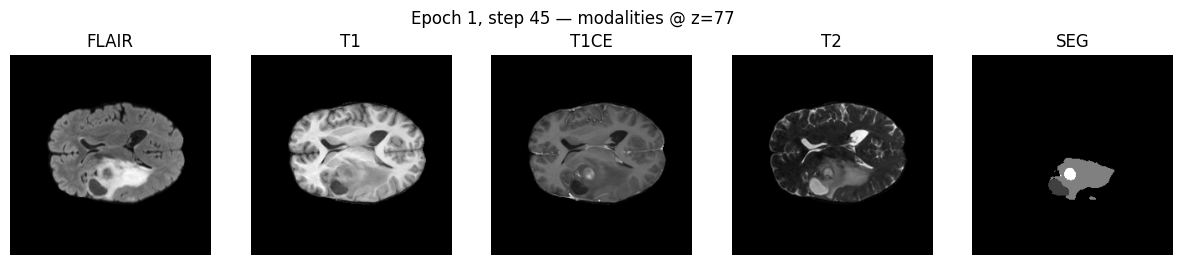

Epoch 1/30:  98%|█████████▊| 90/92 [03:04<00:04,  2.19s/it]

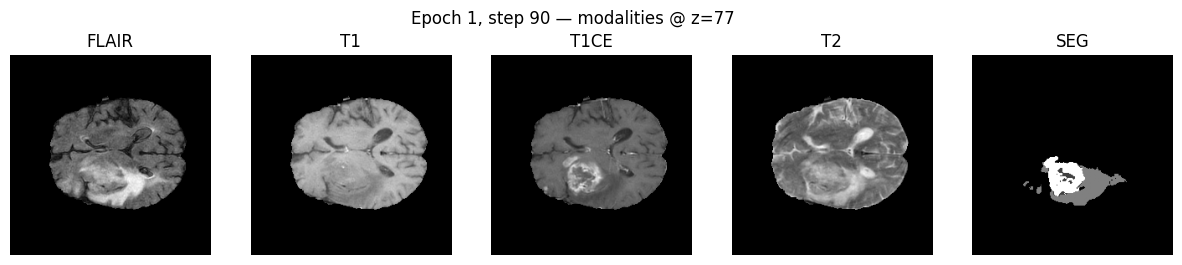

Epoch 1/30: 100%|██████████| 92/92 [03:10<00:00,  2.07s/it]


Epoch 01/30  avg loss = 0.90302


Epoch 2/30:  49%|████▉     | 45/92 [01:22<01:20,  1.70s/it]

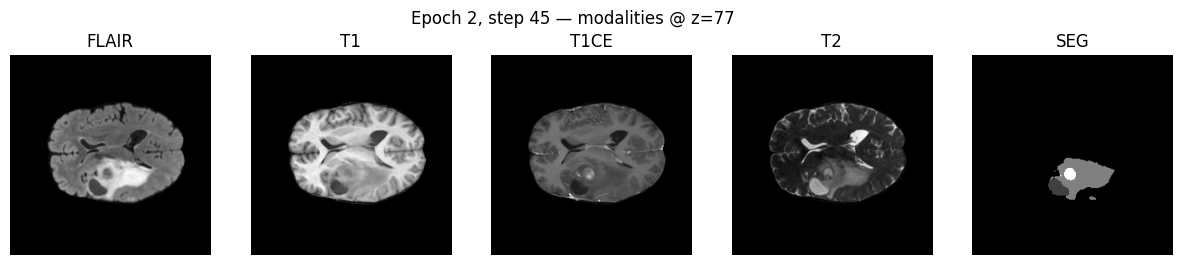

Epoch 2/30:  98%|█████████▊| 90/92 [03:09<00:04,  2.48s/it]

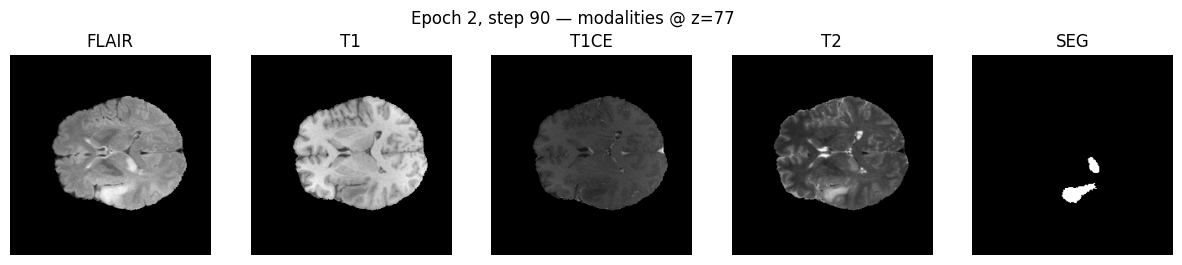

Epoch 2/30: 100%|██████████| 92/92 [03:11<00:00,  2.08s/it]


Epoch 02/30  avg loss = 0.59080


Epoch 3/30:  49%|████▉     | 45/92 [01:24<01:29,  1.90s/it]

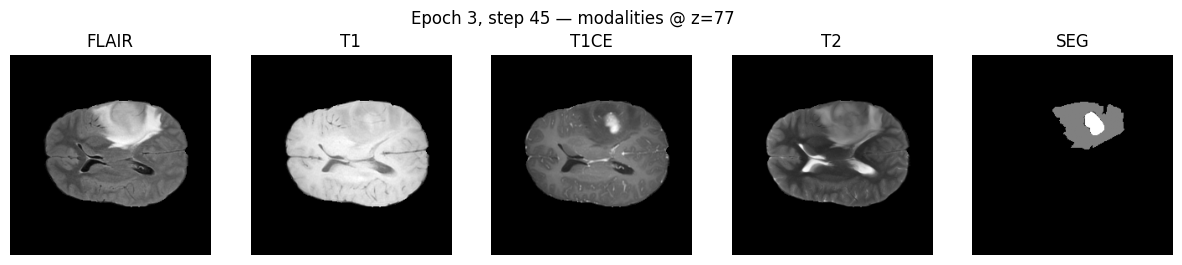

Epoch 3/30:  98%|█████████▊| 90/92 [03:06<00:04,  2.37s/it]

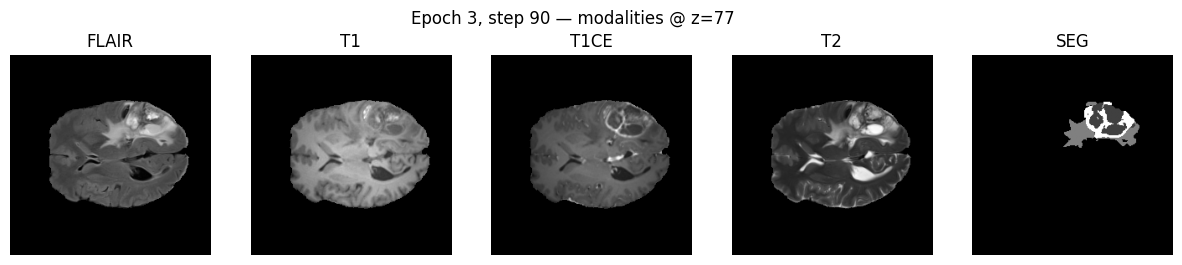

Epoch 3/30: 100%|██████████| 92/92 [03:11<00:00,  2.08s/it]


Epoch 03/30  avg loss = 0.65052


Epoch 4/30:  49%|████▉     | 45/92 [01:24<02:37,  3.35s/it]

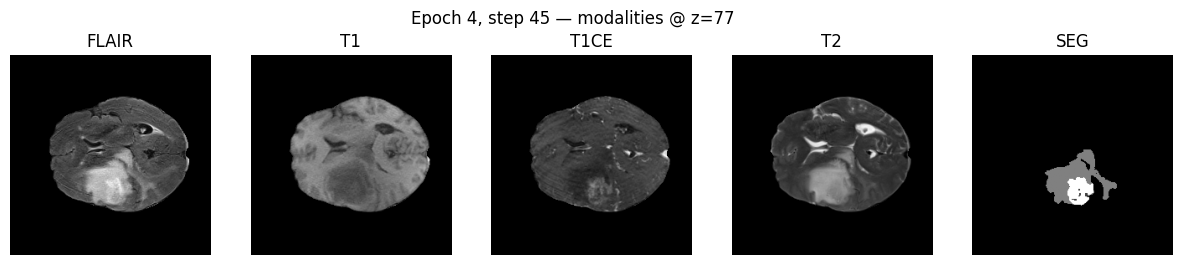

Epoch 4/30:  98%|█████████▊| 90/92 [03:04<00:03,  1.84s/it]

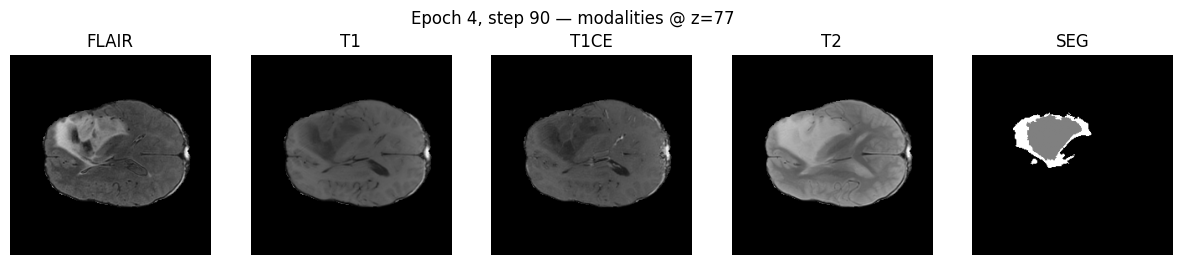

Epoch 4/30: 100%|██████████| 92/92 [03:11<00:00,  2.08s/it]


Epoch 04/30  avg loss = 0.76294


Epoch 5/30:  49%|████▉     | 45/92 [01:26<01:49,  2.33s/it]

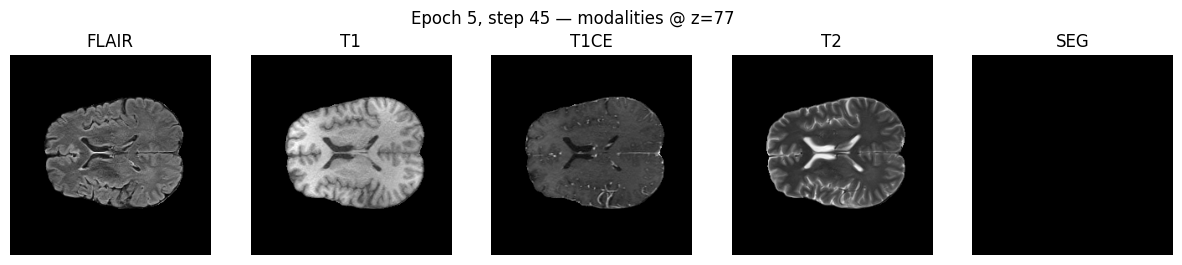

Epoch 5/30:  98%|█████████▊| 90/92 [03:09<00:04,  2.47s/it]

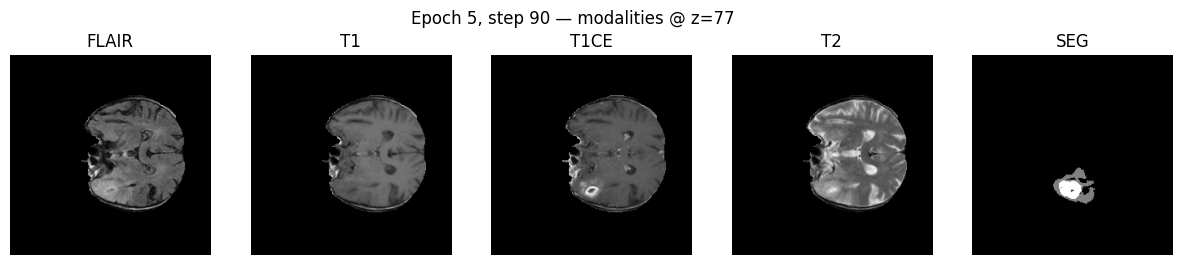

Epoch 5/30: 100%|██████████| 92/92 [03:11<00:00,  2.08s/it]


Epoch 05/30  avg loss = 0.41131


Epoch 6/30:  49%|████▉     | 45/92 [01:23<01:15,  1.60s/it]

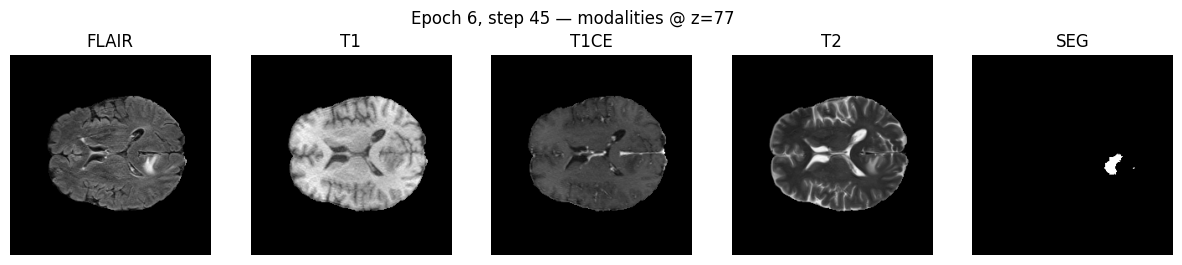

Epoch 6/30:  98%|█████████▊| 90/92 [03:04<00:04,  2.36s/it]

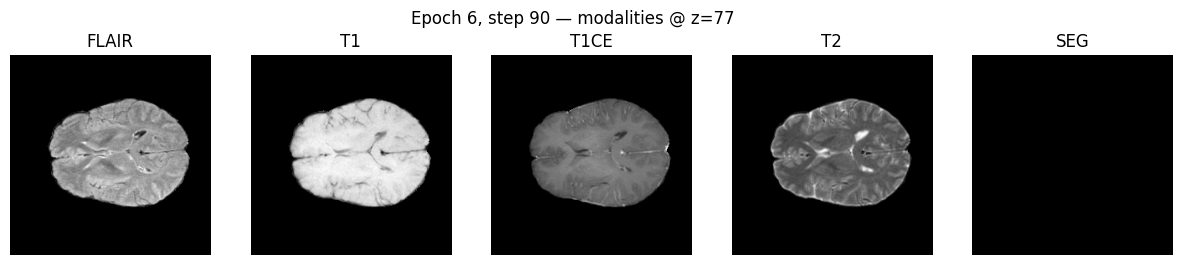

Epoch 6/30: 100%|██████████| 92/92 [03:07<00:00,  2.04s/it]


Epoch 06/30  avg loss = 0.28719


Epoch 7/30:  49%|████▉     | 45/92 [01:17<01:12,  1.53s/it]

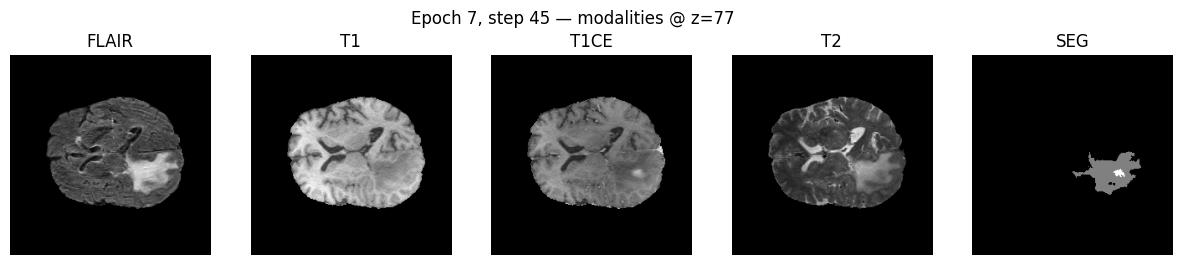

Epoch 7/30:  98%|█████████▊| 90/92 [03:01<00:05,  2.69s/it]

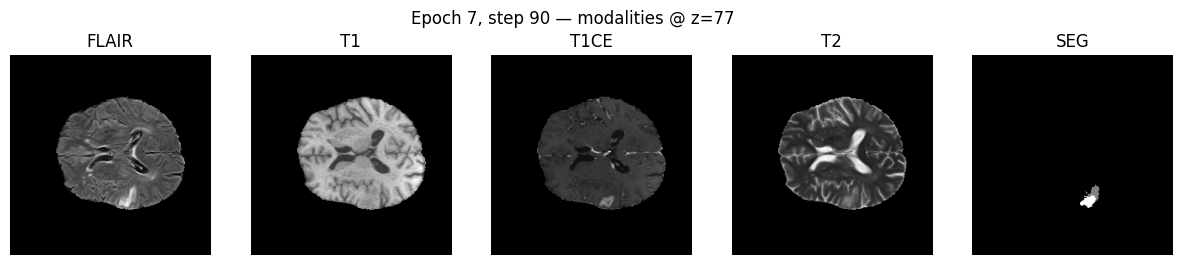

Epoch 7/30: 100%|██████████| 92/92 [03:03<00:00,  2.00s/it]


Epoch 07/30  avg loss = 0.32004


Epoch 8/30:  48%|████▊     | 44/92 [01:26<02:11,  2.74s/it]

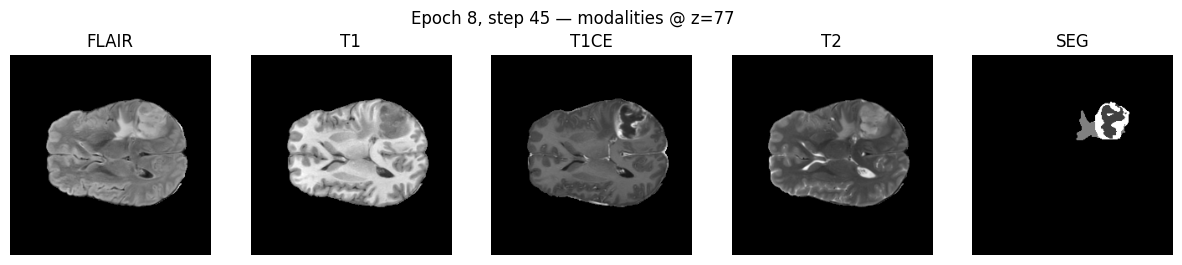

Epoch 8/30:  98%|█████████▊| 90/92 [03:06<00:03,  1.83s/it]

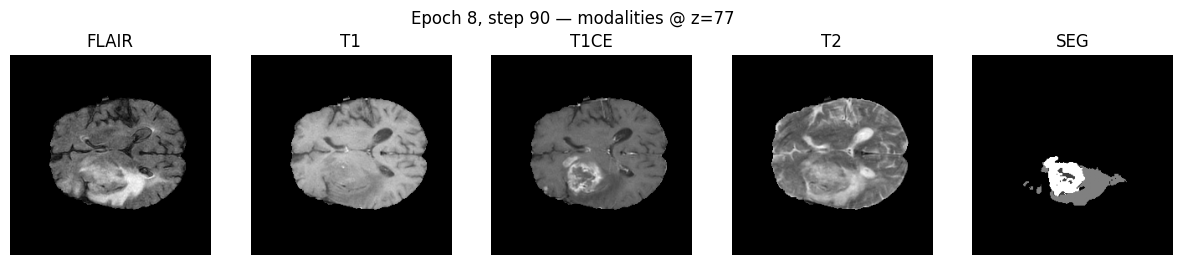

Epoch 8/30: 100%|██████████| 92/92 [03:11<00:00,  2.08s/it]


Epoch 08/30  avg loss = 0.32854


Epoch 9/30:  49%|████▉     | 45/92 [01:15<01:23,  1.79s/it]

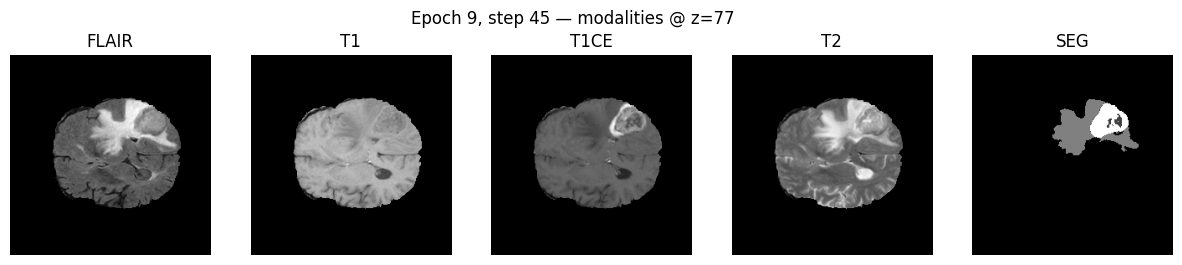

Epoch 9/30:  98%|█████████▊| 90/92 [02:54<00:04,  2.42s/it]

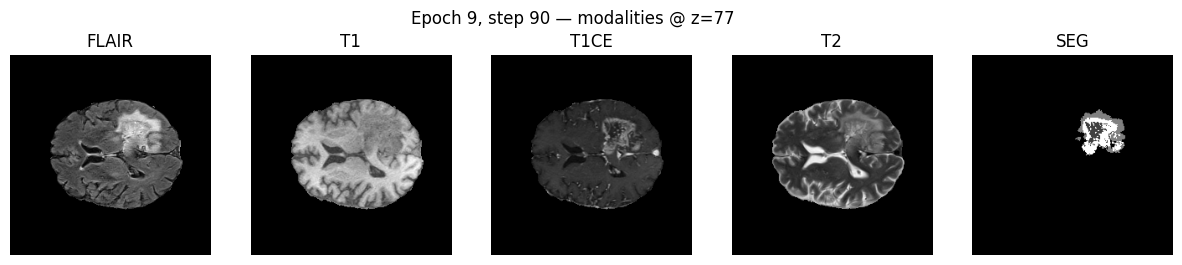

Epoch 9/30: 100%|██████████| 92/92 [02:59<00:00,  1.95s/it]


Epoch 09/30  avg loss = 0.32330


Epoch 10/30:  49%|████▉     | 45/92 [01:24<01:39,  2.12s/it]

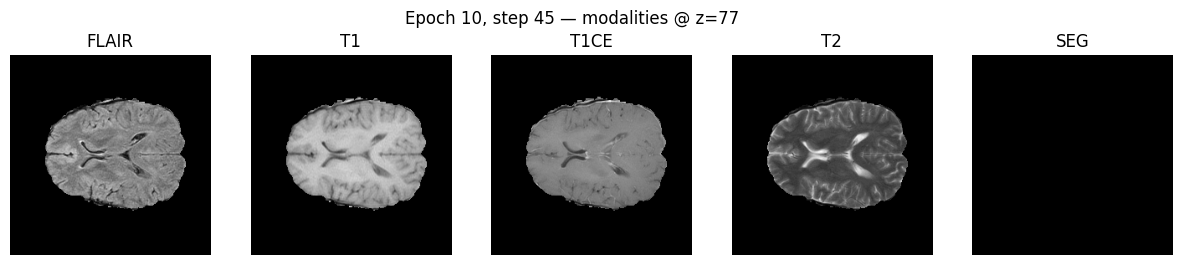

Epoch 10/30:  98%|█████████▊| 90/92 [03:05<00:05,  2.63s/it]

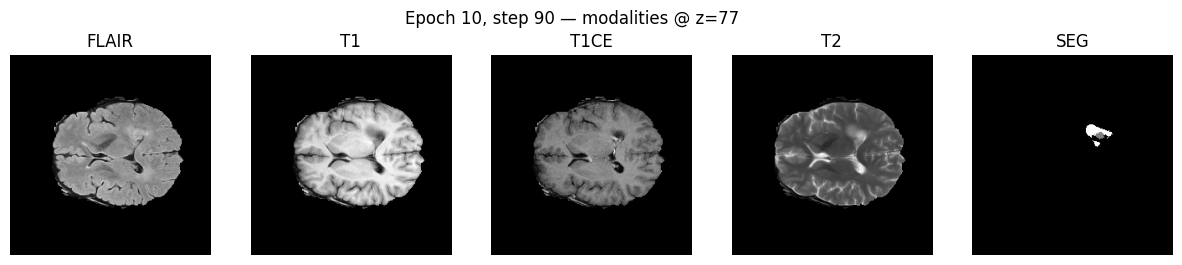

Epoch 10/30: 100%|██████████| 92/92 [03:07<00:00,  2.04s/it]


Epoch 10/30  avg loss = 0.34589


Epoch 11/30:  49%|████▉     | 45/92 [01:23<01:57,  2.50s/it]

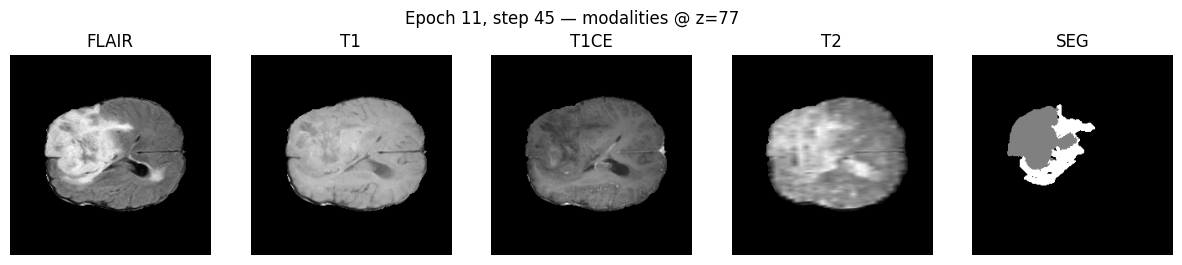

Epoch 11/30:  98%|█████████▊| 90/92 [02:58<00:03,  1.70s/it]

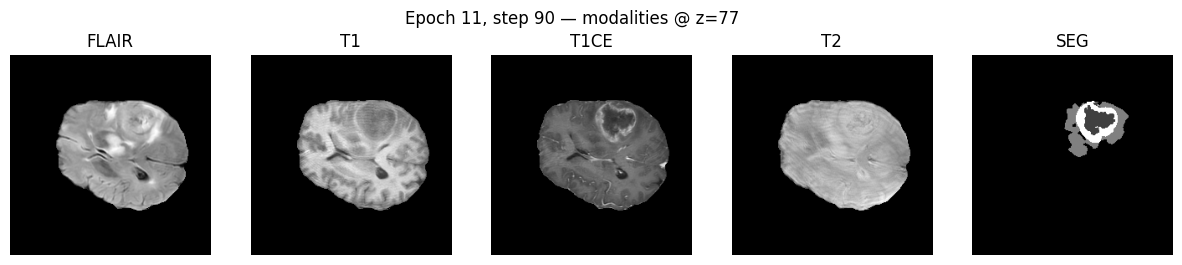

Epoch 11/30: 100%|██████████| 92/92 [03:03<00:00,  2.00s/it]


Epoch 11/30  avg loss = 0.33234


Epoch 12/30:  49%|████▉     | 45/92 [01:26<01:58,  2.53s/it]

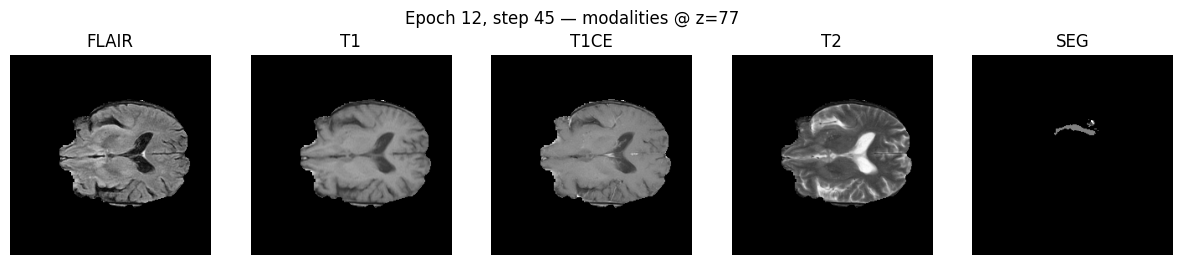

Epoch 12/30:  98%|█████████▊| 90/92 [03:05<00:04,  2.13s/it]

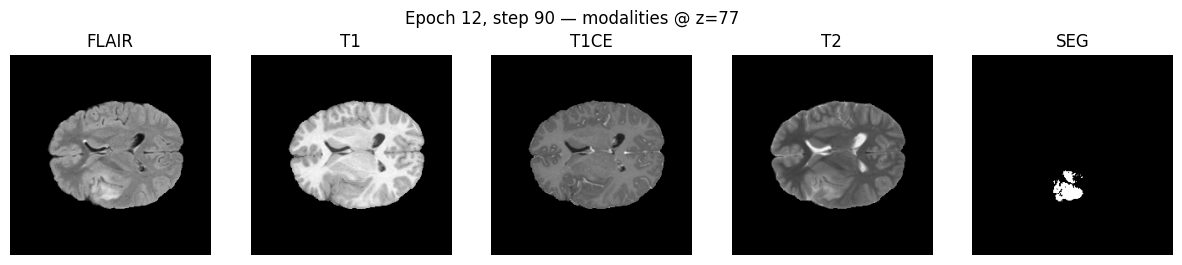

Epoch 12/30: 100%|██████████| 92/92 [03:10<00:00,  2.07s/it]


Epoch 12/30  avg loss = 0.31112


Epoch 13/30:  49%|████▉     | 45/92 [01:15<01:04,  1.37s/it]

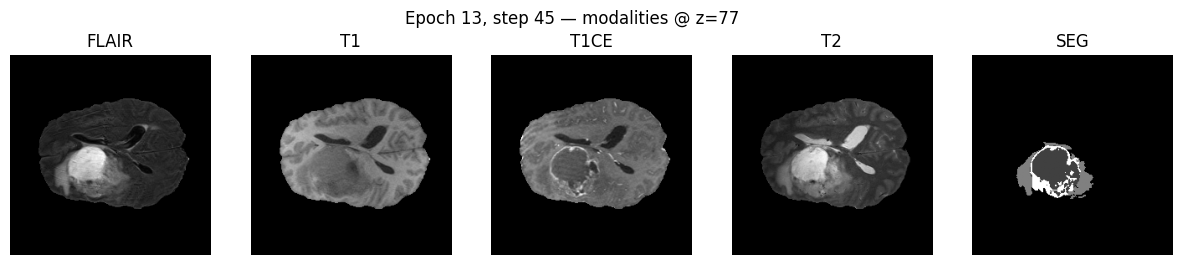

Epoch 13/30:  98%|█████████▊| 90/92 [02:51<00:03,  1.73s/it]

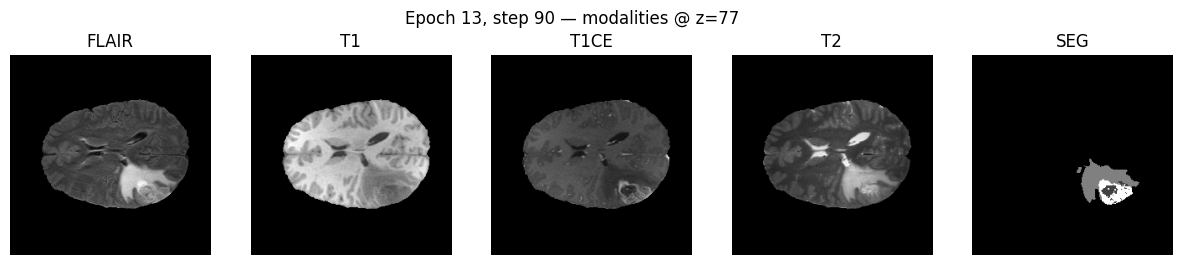

Epoch 13/30: 100%|██████████| 92/92 [02:58<00:00,  1.94s/it]


Epoch 13/30  avg loss = 0.29925


Epoch 14/30:  49%|████▉     | 45/92 [01:18<01:24,  1.80s/it]

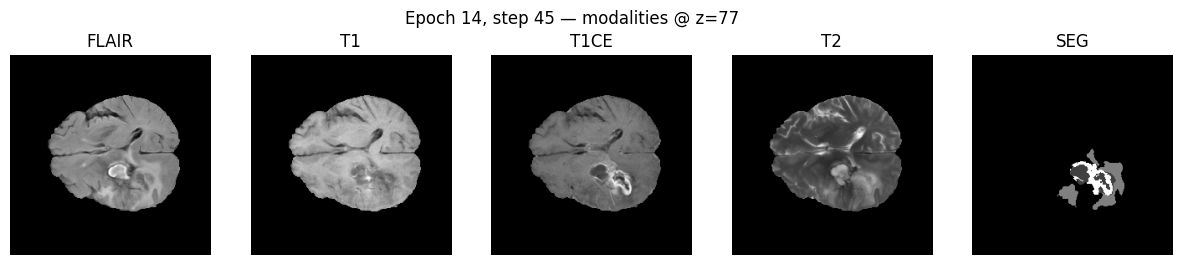

Epoch 14/30:  98%|█████████▊| 90/92 [02:59<00:03,  1.86s/it]

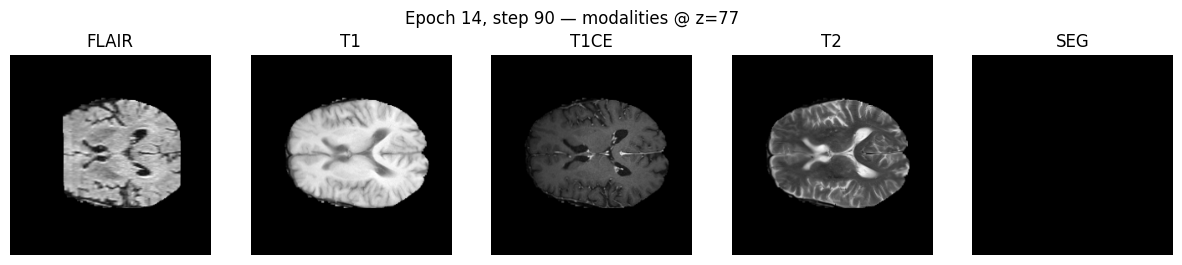

Epoch 14/30: 100%|██████████| 92/92 [03:04<00:00,  2.01s/it]


Epoch 14/30  avg loss = 0.29174


Epoch 15/30:  49%|████▉     | 45/92 [01:20<01:43,  2.21s/it]

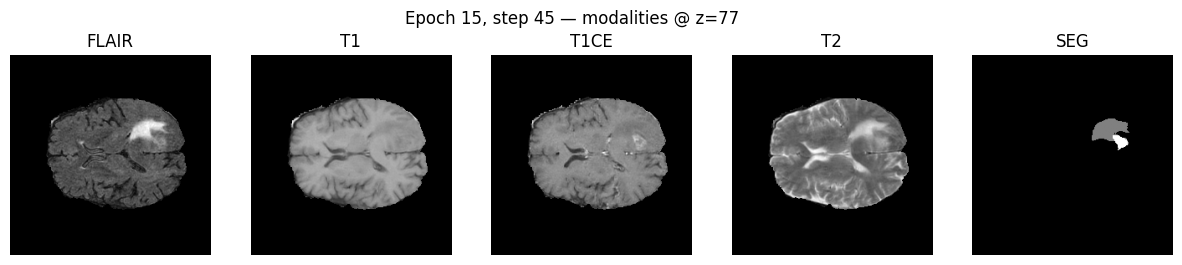

Epoch 15/30:  98%|█████████▊| 90/92 [02:57<00:03,  1.82s/it]

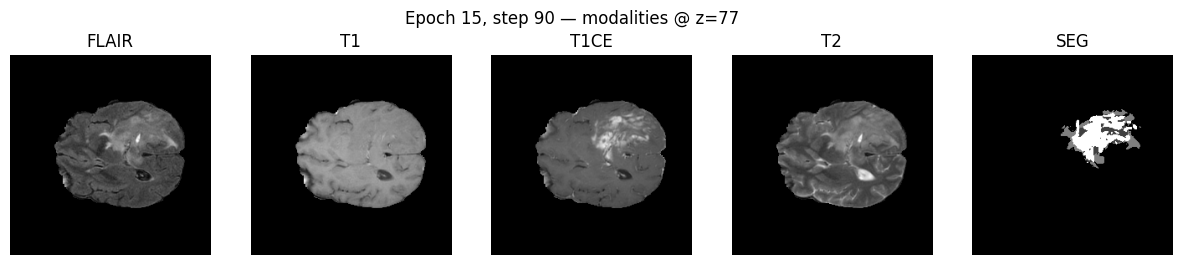

Epoch 15/30: 100%|██████████| 92/92 [03:02<00:00,  1.98s/it]


Epoch 15/30  avg loss = 0.28508


Epoch 16/30:  48%|████▊     | 44/92 [01:25<02:43,  3.41s/it]

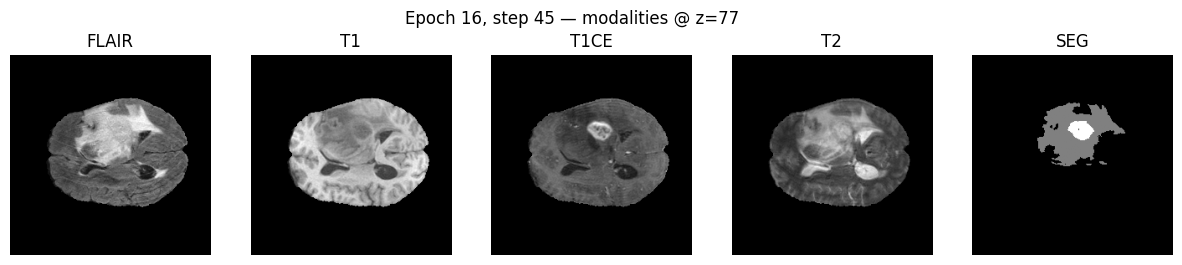

Epoch 16/30:  98%|█████████▊| 90/92 [03:04<00:05,  2.87s/it]

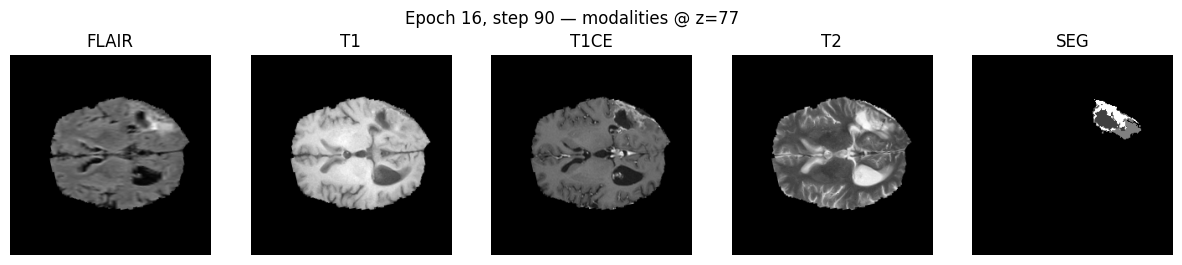

Epoch 16/30: 100%|██████████| 92/92 [03:05<00:00,  2.02s/it]


Epoch 16/30  avg loss = 0.28320


Epoch 17/30:  49%|████▉     | 45/92 [01:18<01:33,  1.99s/it]

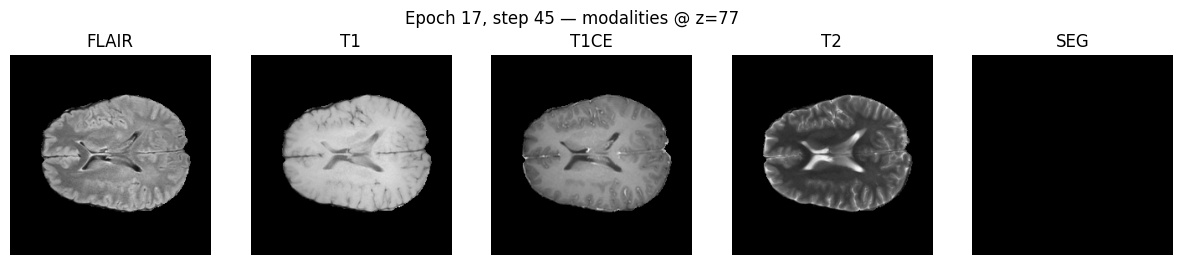

Epoch 17/30:  98%|█████████▊| 90/92 [03:00<00:03,  1.74s/it]

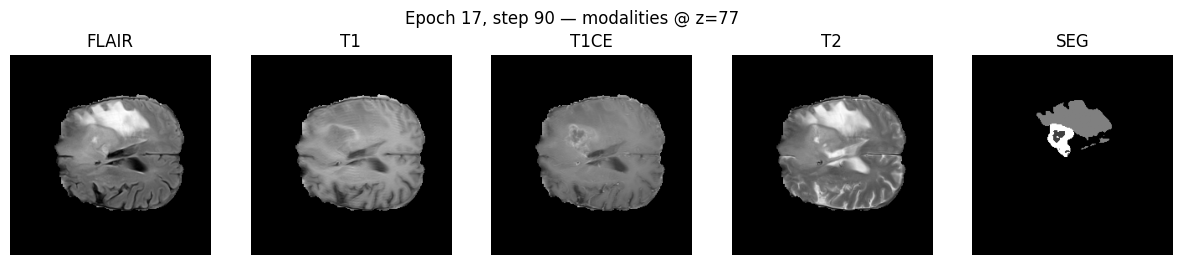

Epoch 17/30: 100%|██████████| 92/92 [03:06<00:00,  2.02s/it]


Epoch 17/30  avg loss = 0.27536


Epoch 18/30:  49%|████▉     | 45/92 [01:23<02:49,  3.60s/it]

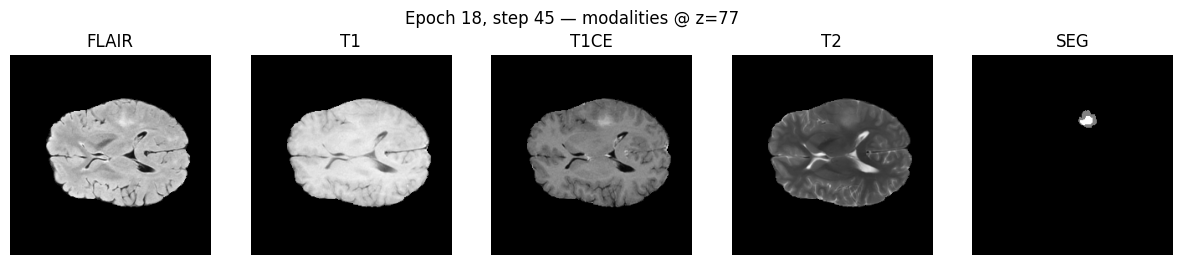

Epoch 18/30:  98%|█████████▊| 90/92 [02:57<00:03,  1.79s/it]

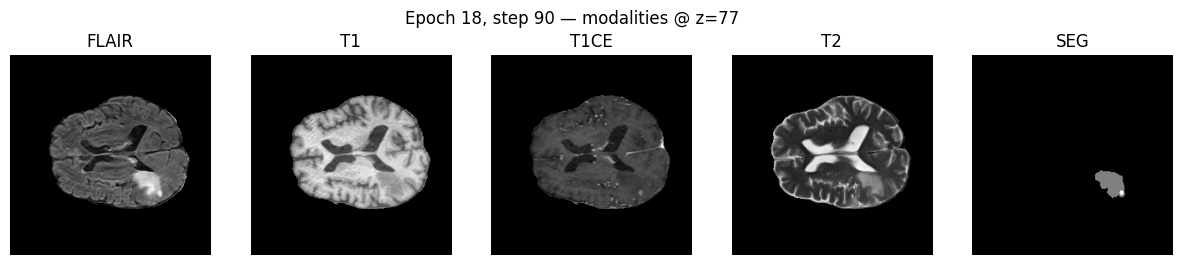

Epoch 18/30: 100%|██████████| 92/92 [03:01<00:00,  1.97s/it]


Epoch 18/30  avg loss = 0.26714


Epoch 19/30:  49%|████▉     | 45/92 [01:19<01:18,  1.67s/it]

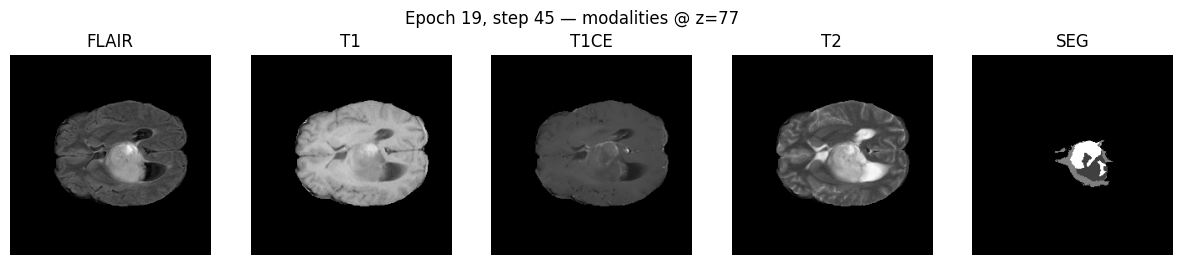

Epoch 19/30:  97%|█████████▋| 89/92 [03:01<00:05,  1.90s/it]

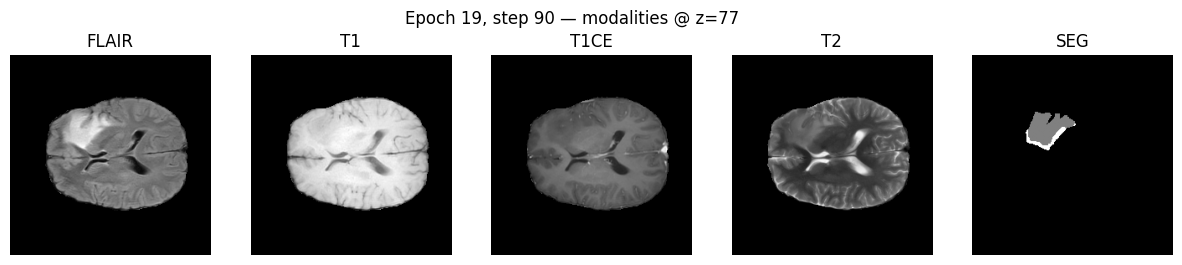

Epoch 19/30: 100%|██████████| 92/92 [03:08<00:00,  2.04s/it]


Epoch 19/30  avg loss = 0.26897


Epoch 20/30:  49%|████▉     | 45/92 [01:22<01:45,  2.24s/it]

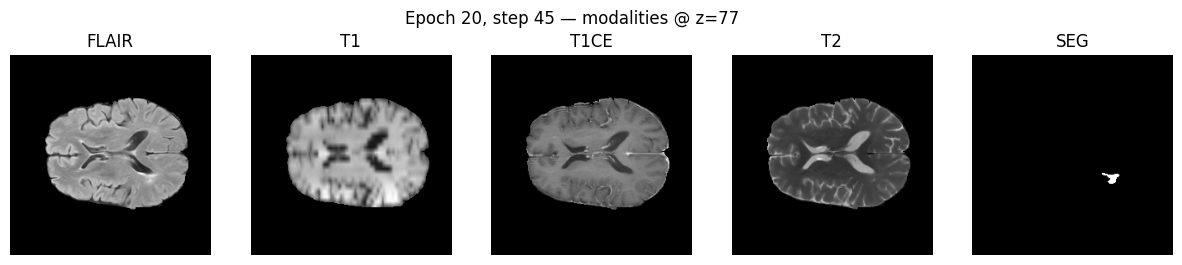

Epoch 20/30:  97%|█████████▋| 89/92 [03:03<00:08,  2.89s/it]

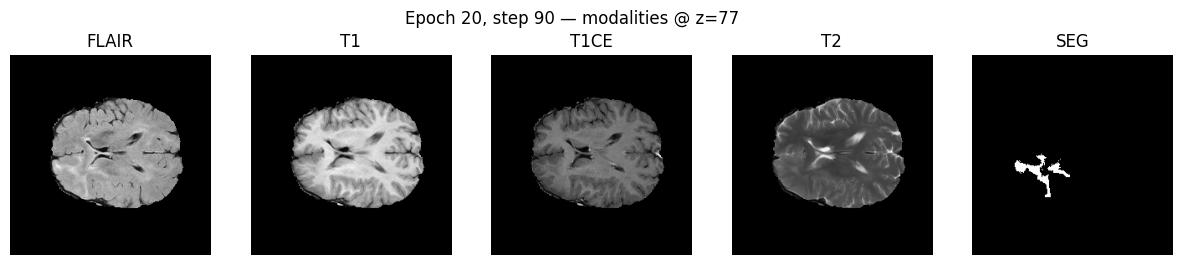

Epoch 20/30: 100%|██████████| 92/92 [03:04<00:00,  2.01s/it]


Epoch 20/30  avg loss = 0.26662


Epoch 21/30:  49%|████▉     | 45/92 [01:21<01:21,  1.73s/it]

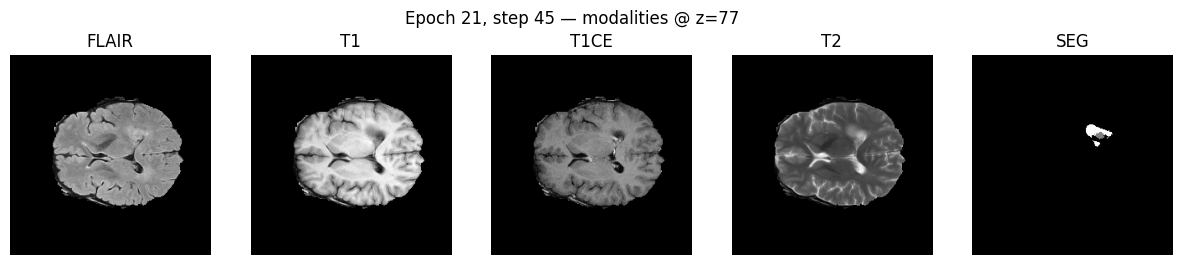

Epoch 21/30:  98%|█████████▊| 90/92 [03:01<00:03,  1.82s/it]

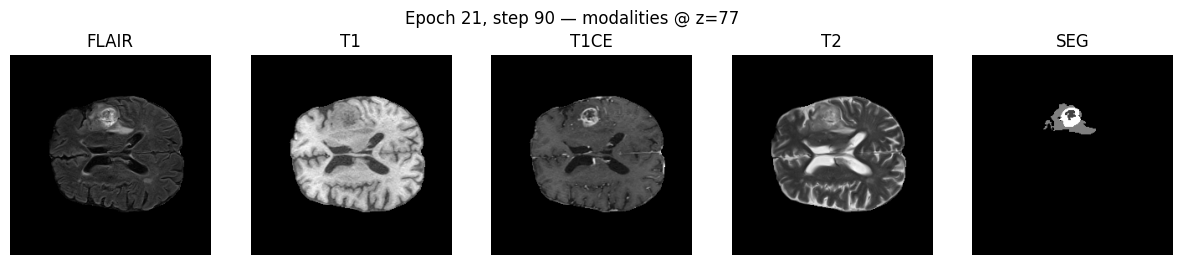

Epoch 21/30: 100%|██████████| 92/92 [03:07<00:00,  2.03s/it]


Epoch 21/30  avg loss = 0.27412


Epoch 22/30:  49%|████▉     | 45/92 [01:18<02:03,  2.63s/it]

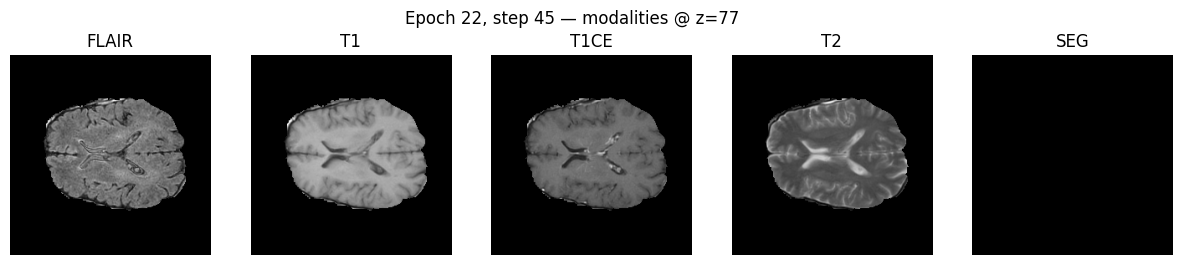

Epoch 22/30:  98%|█████████▊| 90/92 [02:59<00:04,  2.25s/it]

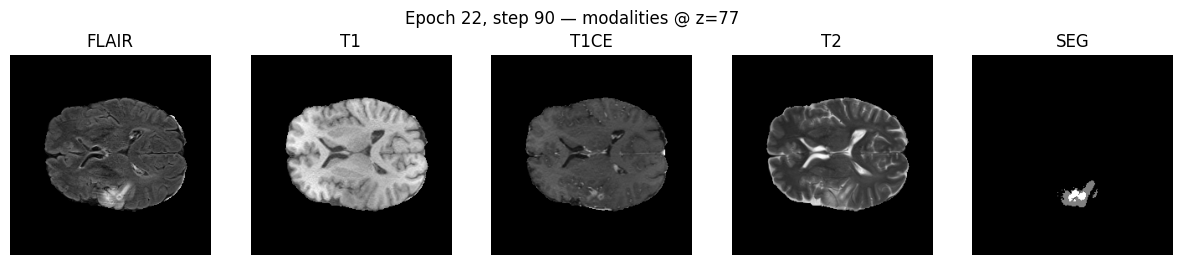

Epoch 22/30: 100%|██████████| 92/92 [03:02<00:00,  1.98s/it]


Epoch 22/30  avg loss = 0.27524


Epoch 23/30:  48%|████▊     | 44/92 [01:20<01:23,  1.74s/it]

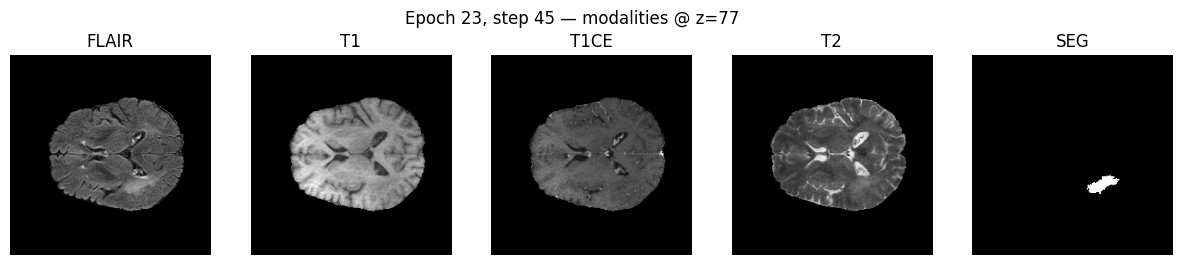

Epoch 23/30:  98%|█████████▊| 90/92 [03:07<00:05,  3.00s/it]

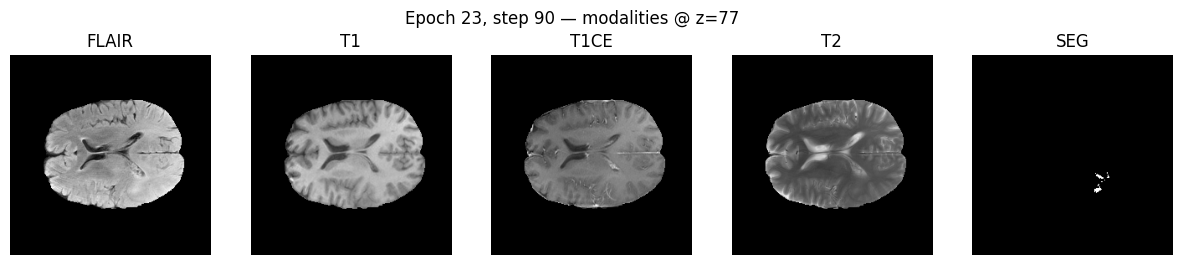

Epoch 23/30: 100%|██████████| 92/92 [03:09<00:00,  2.06s/it]


Epoch 23/30  avg loss = 0.26150


Epoch 24/30:  49%|████▉     | 45/92 [01:22<01:42,  2.17s/it]

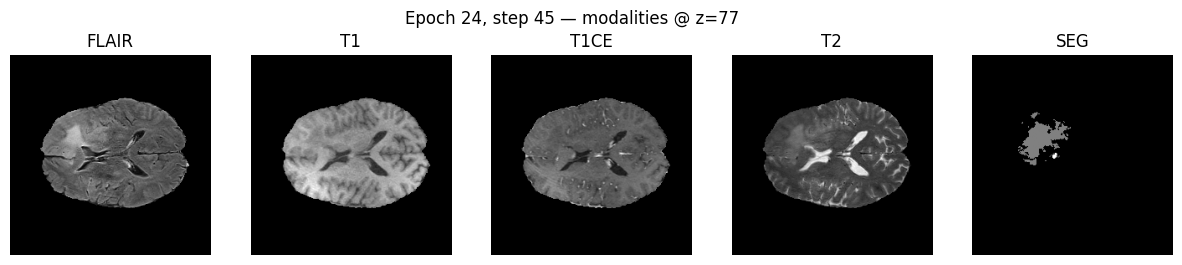

Epoch 24/30:  98%|█████████▊| 90/92 [03:01<00:05,  2.92s/it]

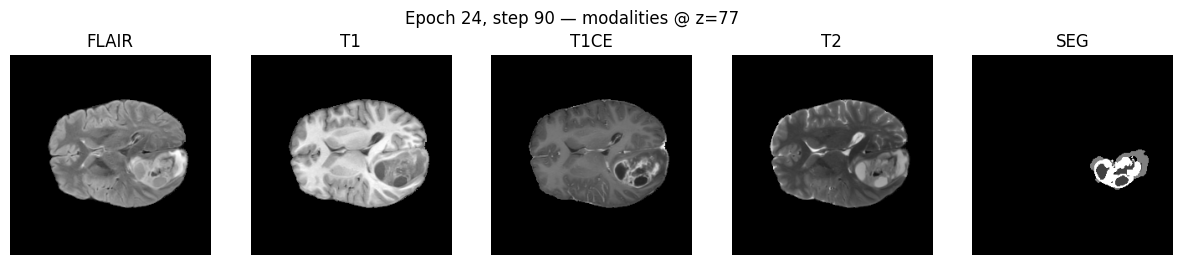

Epoch 24/30: 100%|██████████| 92/92 [03:03<00:00,  2.00s/it]


Epoch 24/30  avg loss = 0.25363


Epoch 25/30:  49%|████▉     | 45/92 [01:22<01:25,  1.82s/it]

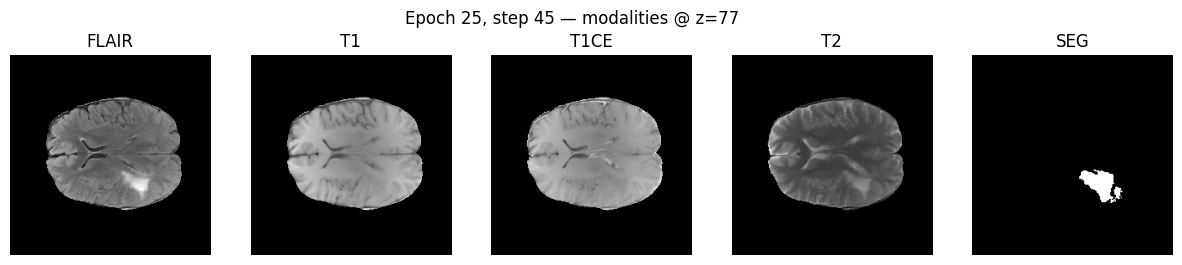

Epoch 25/30:  98%|█████████▊| 90/92 [03:03<00:04,  2.15s/it]

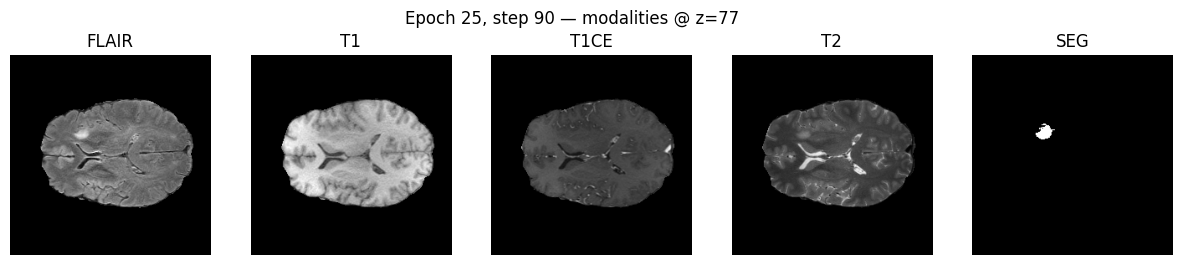

Epoch 25/30: 100%|██████████| 92/92 [03:09<00:00,  2.06s/it]


Epoch 25/30  avg loss = 0.24212


Epoch 26/30:  48%|████▊     | 44/92 [01:13<01:30,  1.89s/it]

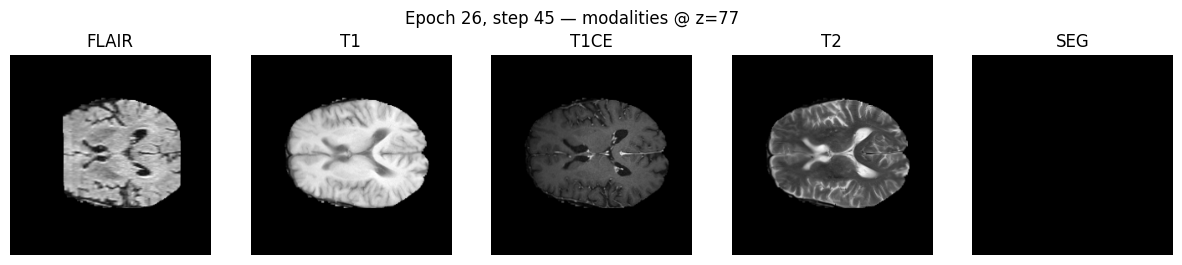

Epoch 26/30:  98%|█████████▊| 90/92 [02:56<00:03,  1.64s/it]

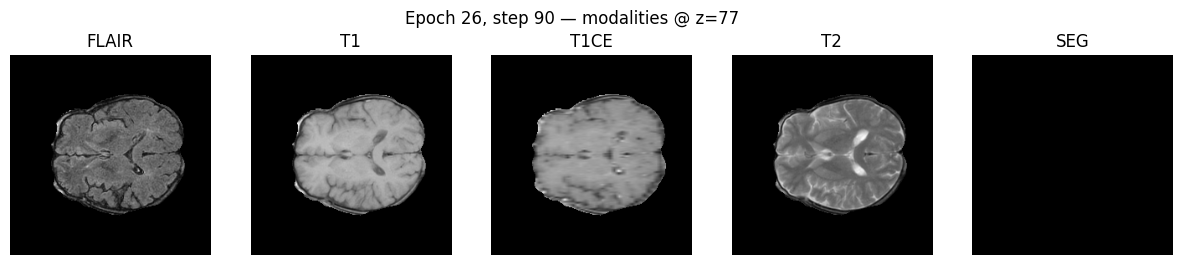

Epoch 26/30: 100%|██████████| 92/92 [03:02<00:00,  1.98s/it]


Epoch 26/30  avg loss = 0.24157


Epoch 27/30:  49%|████▉     | 45/92 [01:21<02:00,  2.57s/it]

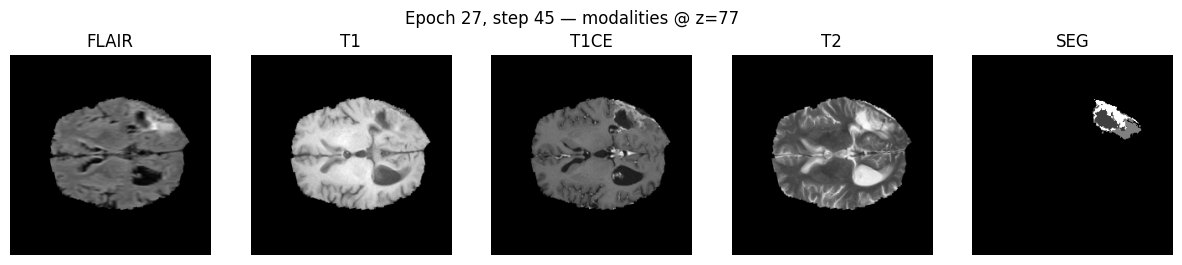

Epoch 27/30:  98%|█████████▊| 90/92 [03:01<00:02,  1.49s/it]

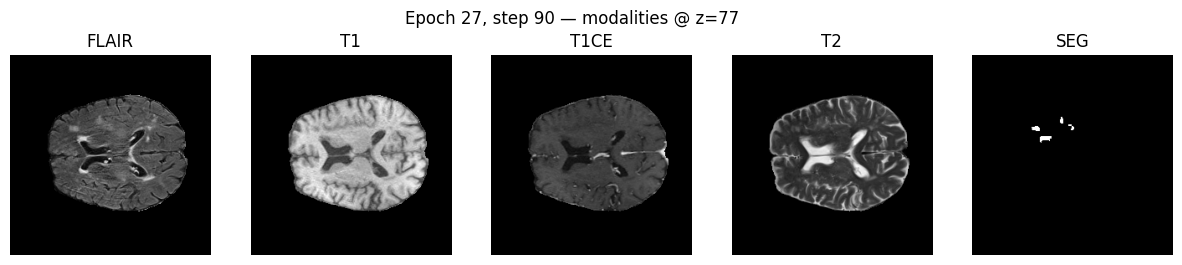

Epoch 27/30: 100%|██████████| 92/92 [03:08<00:00,  2.05s/it]


Epoch 27/30  avg loss = 0.24831


Epoch 28/30:  49%|████▉     | 45/92 [01:24<02:18,  2.95s/it]

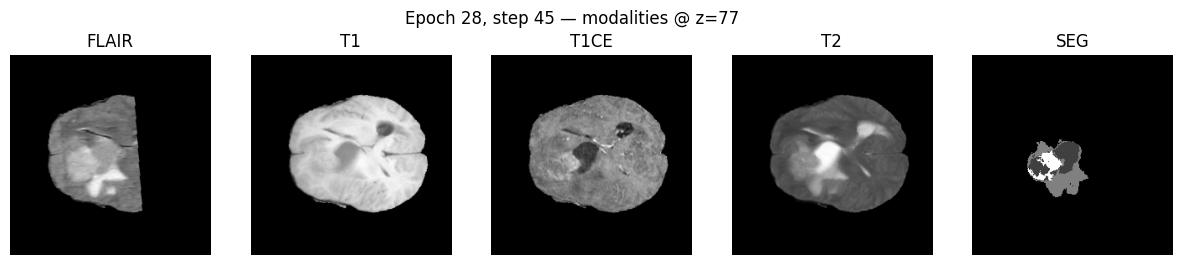

Epoch 28/30:  98%|█████████▊| 90/92 [03:03<00:04,  2.21s/it]

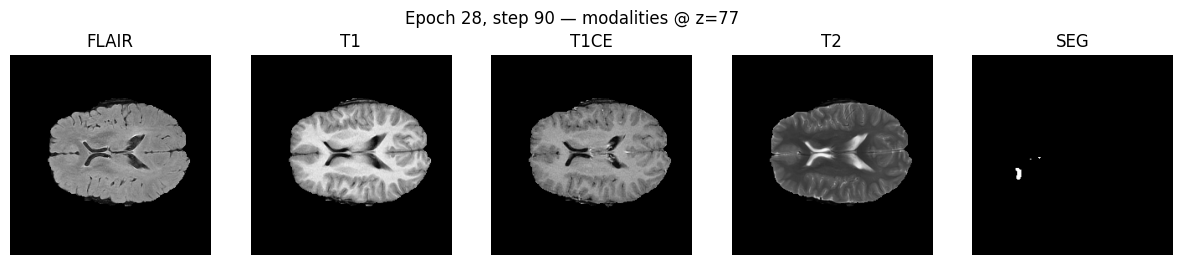

Epoch 28/30: 100%|██████████| 92/92 [03:06<00:00,  2.03s/it]


Epoch 28/30  avg loss = 0.25053


Epoch 29/30:  49%|████▉     | 45/92 [01:22<01:28,  1.89s/it]

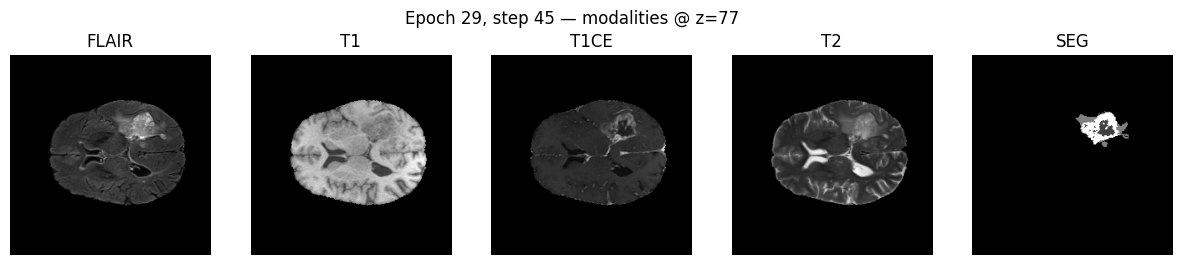

Epoch 29/30:  98%|█████████▊| 90/92 [03:04<00:03,  1.80s/it]

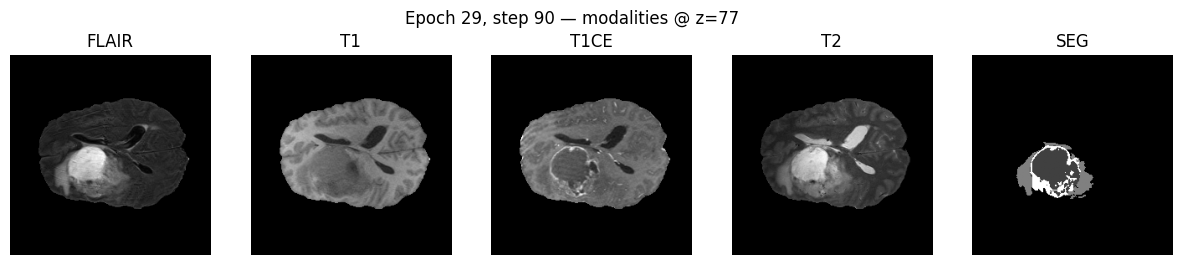

Epoch 29/30: 100%|██████████| 92/92 [03:09<00:00,  2.06s/it]


Epoch 29/30  avg loss = 0.24846


Epoch 30/30:  49%|████▉     | 45/92 [01:26<01:51,  2.38s/it]

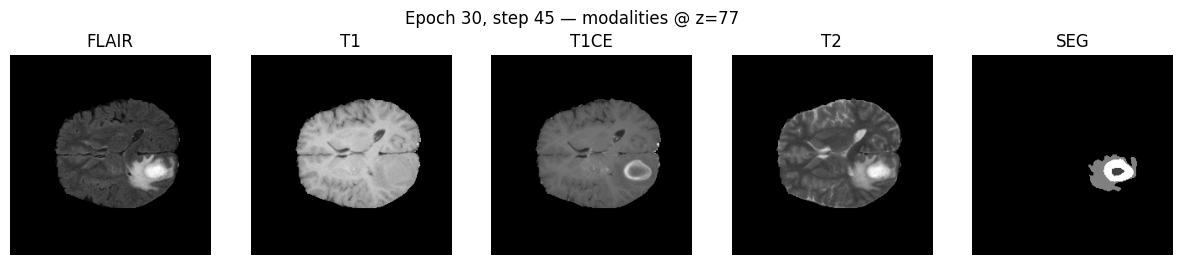

Epoch 30/30:  97%|█████████▋| 89/92 [03:06<00:05,  1.86s/it]

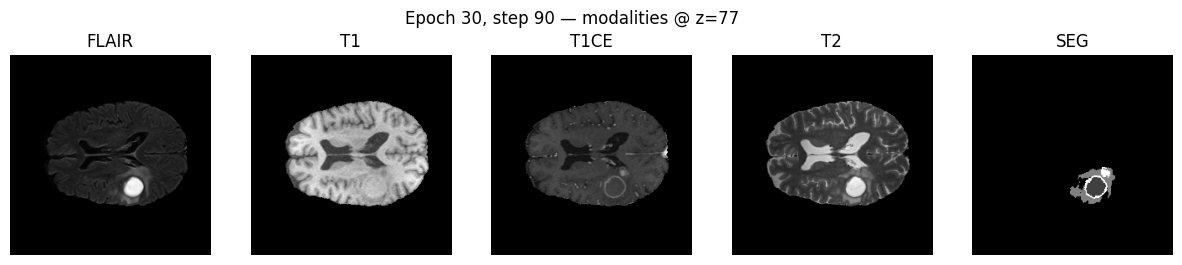

Epoch 30/30: 100%|██████████| 92/92 [03:12<00:00,  2.09s/it]


Epoch 30/30  avg loss = 0.24369
Picked file: /content/drive/MyDrive/brats_saved/flair/BraTS20_Training_156_flair_ep01_st045.nii
Shape is: (240, 240, 155)


In [ ]:
# #──────────────────────────────────────────────────────────
# # 10) Training loop with periodic visualization (does not save generated images)
# #──────────────────────────────────────────────────────────

# # NII save path
# OUTPUT_ROOT = '/content/drive/MyDrive/brats_saved'
# MODS = ['flair','t1','t1ce','t2','seg']
# for m in MODS:
#     os.makedirs(os.path.join(OUTPUT_ROOT, m), exist_ok=True)

# for epoch in range(1, EPOCHS+1):
#     total = tf.constant(0.0, tf.float32)
#     steps = tf.constant(0, tf.int32)

#     with tqdm(total=tf.data.experimental.cardinality(ds).numpy(),
#               desc=f"Epoch {epoch}/{EPOCHS}") as pbar:
#         for window_batch, path_batch in ds:
#             loss = train_step(window_batch)
#             total += loss
#             steps += 1
#             pbar.update(1)

#             # every 45 steps, show & save modalities only
#             if tf.equal(steps % 45, 0):
#                 fpath = path_batch[0].numpy().decode('utf-8')
#                 subj_dir = os.path.dirname(fpath)


#                 # load FLAIR just to get the central index
#                 flair = nib.load(fpath).get_fdata().astype(np.float32)
#                 mn, mx = flair.min(), flair.max()
#                 flair = (flair - mn)/(mx - mn)*2 - 1
#                 iz = flair.shape[2]//2

#                 # 1×5 figure
#                 fig, axes = plt.subplots(1, len(MODS), figsize=(15,3))
#                 for ax, m in zip(axes, MODS):
#                     # build modality filepath
#                     mod_fn   = os.path.basename(fpath).replace('flair', m)
#                     mod_path = os.path.join(subj_dir, mod_fn)

#                     # load + normalize
#                     vol = nib.load(mod_path).get_fdata().astype(np.float32)
#                     mn, mx = vol.min(), vol.max()
#                     vol = (vol - mn)/(mx - mn)*2 - 1

#                     # save the full volume as .nii
#                     out_fn   = mod_fn.replace('.nii', f'_ep{epoch:02d}_st{steps.numpy():03d}.nii')
#                     out_path = os.path.join(OUTPUT_ROOT, m, out_fn)
#                     nib.save(nib.Nifti1Image(vol, affine=nib.load(mod_path).affine),
#                              out_path)

#                     # extract & show the same axial slice
#                     sl = vol[:, :, iz]
#                     ax.imshow(sl, cmap='gray')
#                     ax.set_title(m.upper())
#                     ax.axis('off')

#                 plt.suptitle(f"Epoch {epoch}, step {steps.numpy()} — modalities @ z={iz}")
#                 plt.show()

#     avg = total / tf.cast(steps, tf.float32)
#     print(f"Epoch {epoch:02d}/{EPOCHS}  avg loss = {avg:.5f}")

# # ----------------------------------------------------------------
# # Pick one saved .nii and show its shape:
# # ----------------------------------------------------------------
# all_flair = glob.glob(os.path.join(OUTPUT_ROOT, 'flair', '*.nii'))
# sample    = all_flair[0]
# nii       = nib.load(sample)
# print("Picked file:", sample)
# print("Shape is:", nii.get_fdata().shape)

Epoch 1/30:  49%|████▉     | 45/92 [02:22<03:11,  4.07s/it]

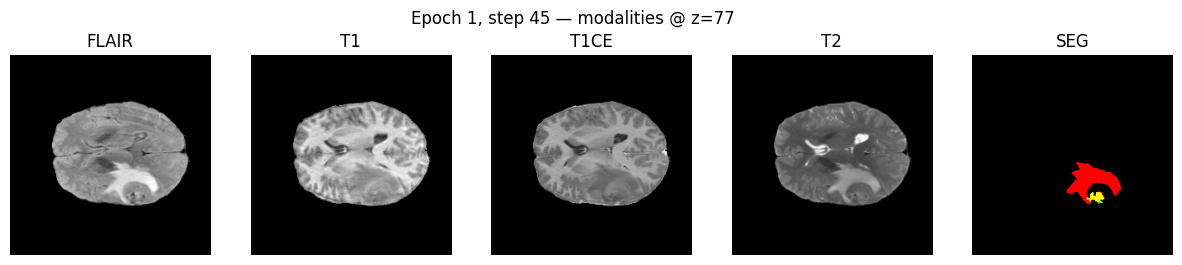

Epoch 1/30:  98%|█████████▊| 90/92 [05:07<00:06,  3.49s/it]<ipython-input-14-01b72ed2005f>:70: RuntimeWarning: divide by zero encountered in divide
  norm_vol = (vol - mn) / (mx - mn) * 2 - 1
<ipython-input-14-01b72ed2005f>:70: RuntimeWarning: invalid value encountered in divide
  norm_vol = (vol - mn) / (mx - mn) * 2 - 1


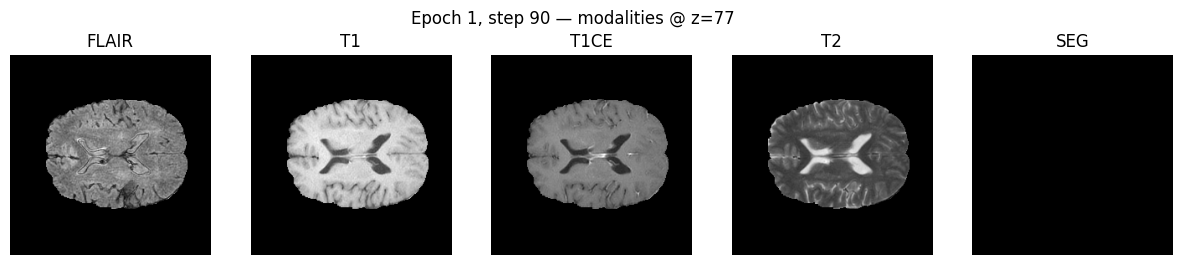

Epoch 1/30: 100%|██████████| 92/92 [05:15<00:00,  3.43s/it]


Epoch 01/30  avg loss = 0.50997


Epoch 2/30:  49%|████▉     | 45/92 [02:04<02:43,  3.47s/it]

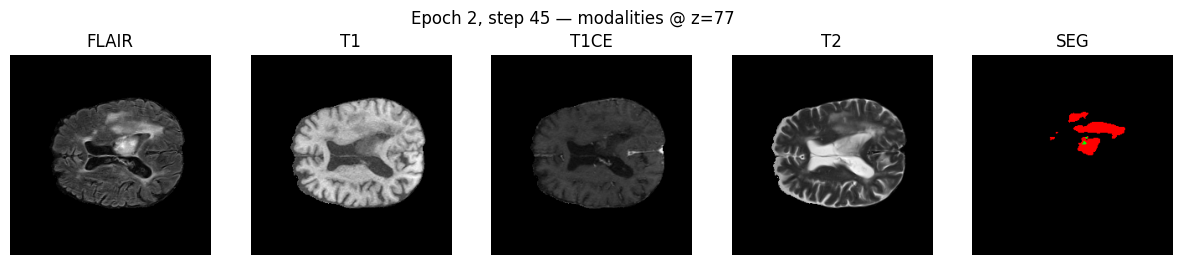

Epoch 2/30:  98%|█████████▊| 90/92 [04:42<00:05,  3.00s/it]

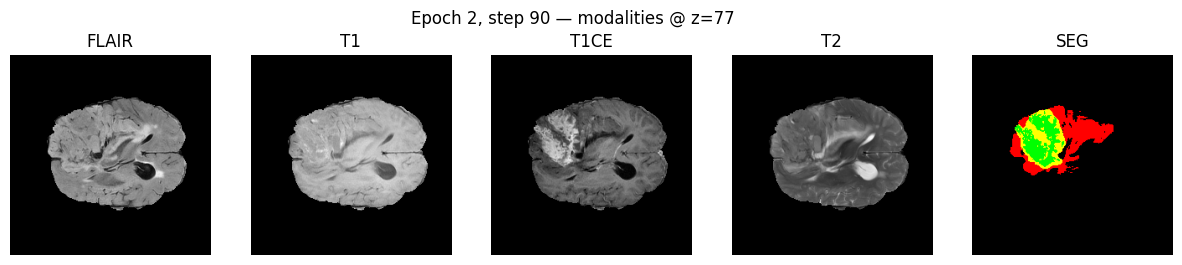

Epoch 2/30: 100%|██████████| 92/92 [04:49<00:00,  3.15s/it]


Epoch 02/30  avg loss = 0.44829


Epoch 3/30:  49%|████▉     | 45/92 [02:03<02:32,  3.25s/it]

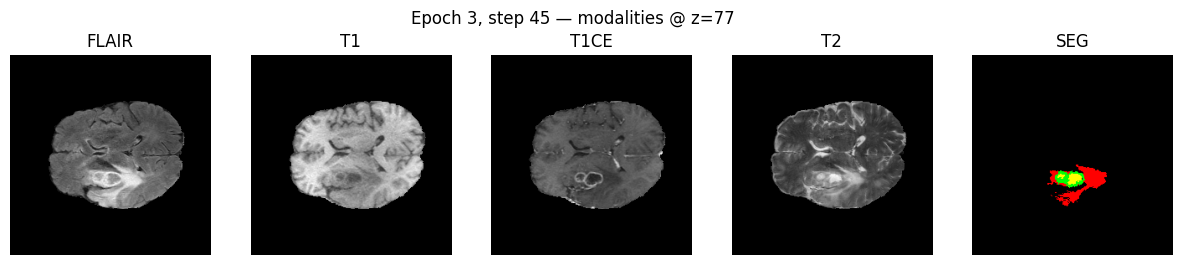

Epoch 3/30:  98%|█████████▊| 90/92 [04:33<00:06,  3.29s/it]

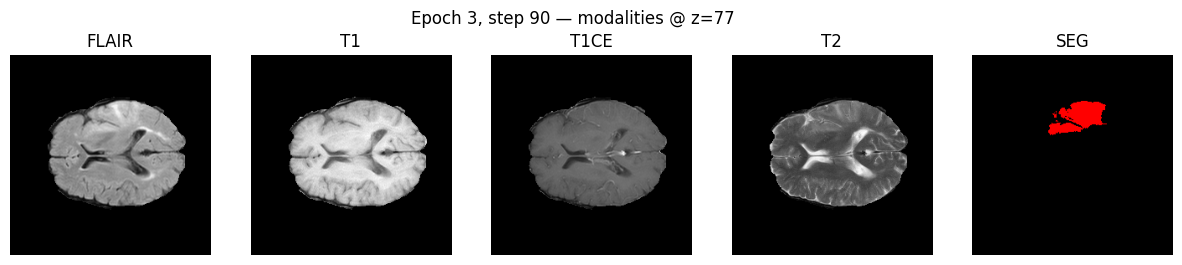

Epoch 3/30: 100%|██████████| 92/92 [04:39<00:00,  3.04s/it]


Epoch 03/30  avg loss = 0.41600


Epoch 4/30:  49%|████▉     | 45/92 [02:05<02:35,  3.30s/it]

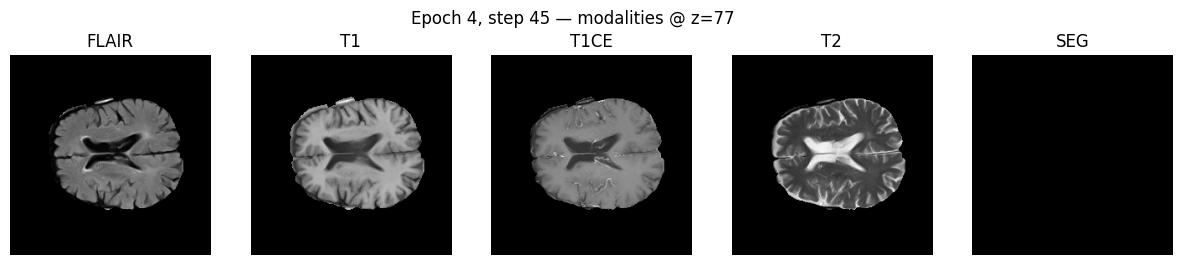

Epoch 4/30:  98%|█████████▊| 90/92 [04:31<00:06,  3.32s/it]

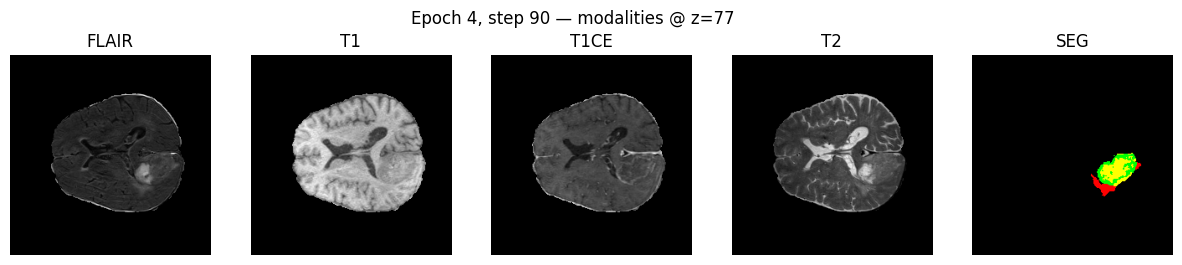

Epoch 4/30: 100%|██████████| 92/92 [04:35<00:00,  3.00s/it]


Epoch 04/30  avg loss = 0.33676


Epoch 5/30:  49%|████▉     | 45/92 [01:49<01:34,  2.01s/it]

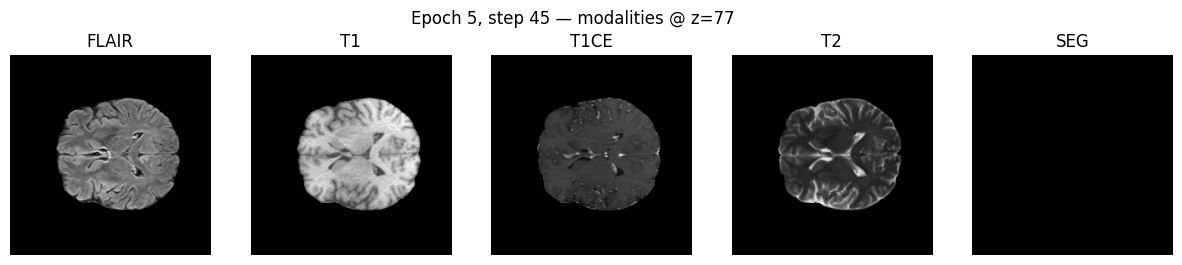

Epoch 5/30:  98%|█████████▊| 90/92 [04:06<00:05,  2.77s/it]

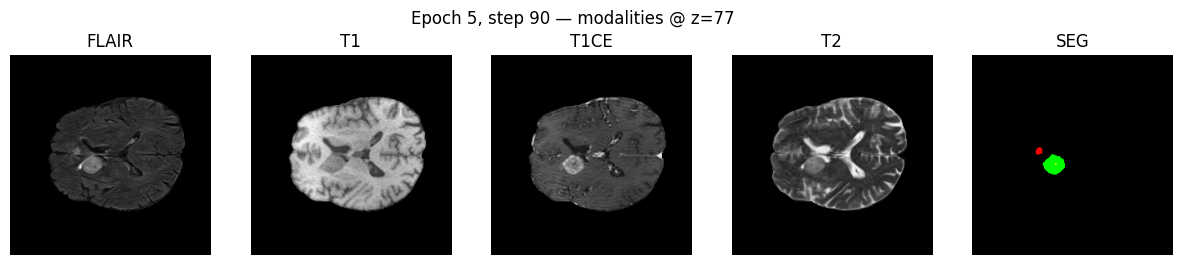

Epoch 5/30: 100%|██████████| 92/92 [04:13<00:00,  2.76s/it]


Epoch 05/30  avg loss = 0.30940


Epoch 6/30:  49%|████▉     | 45/92 [01:46<02:14,  2.85s/it]

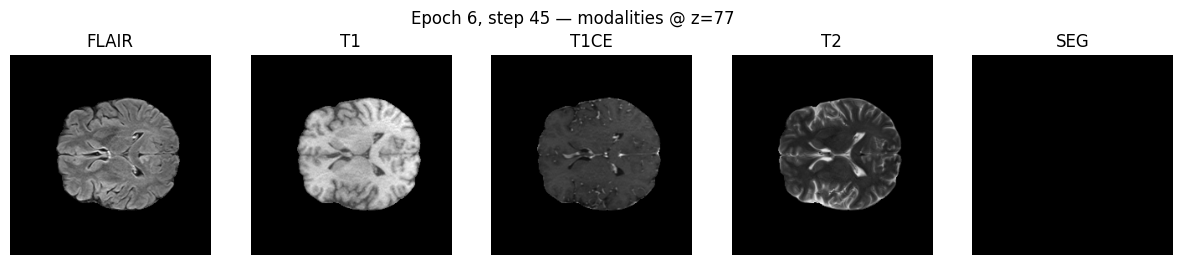

Epoch 6/30:  98%|█████████▊| 90/92 [04:14<00:08,  4.01s/it]

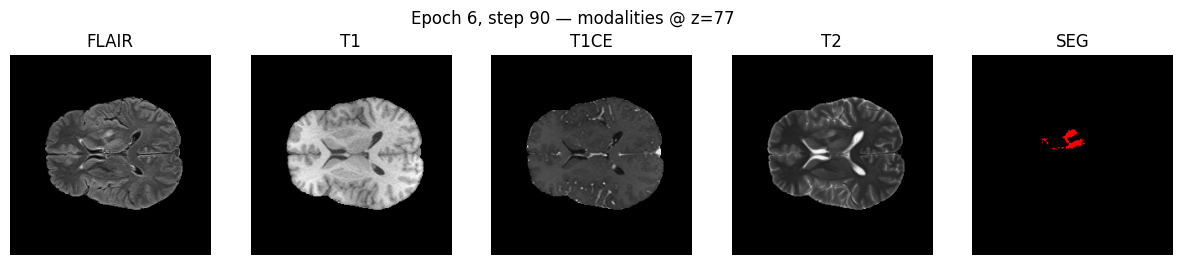

Epoch 6/30: 100%|██████████| 92/92 [04:18<00:00,  2.81s/it]


Epoch 06/30  avg loss = 0.30203


Epoch 7/30:  49%|████▉     | 45/92 [01:48<03:17,  4.21s/it]

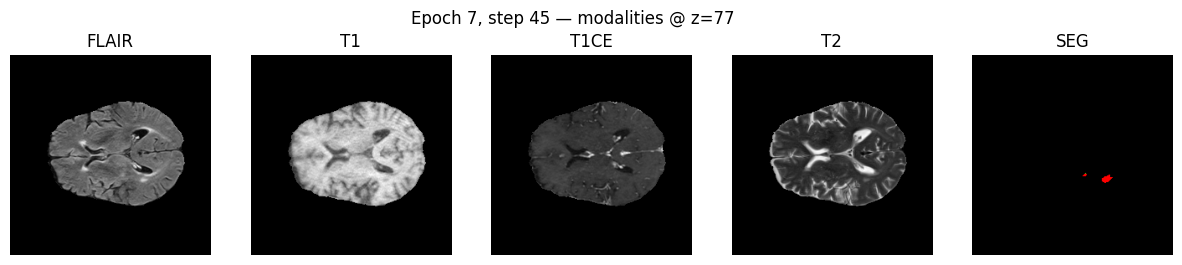

Epoch 7/30:  98%|█████████▊| 90/92 [04:00<00:07,  3.68s/it]

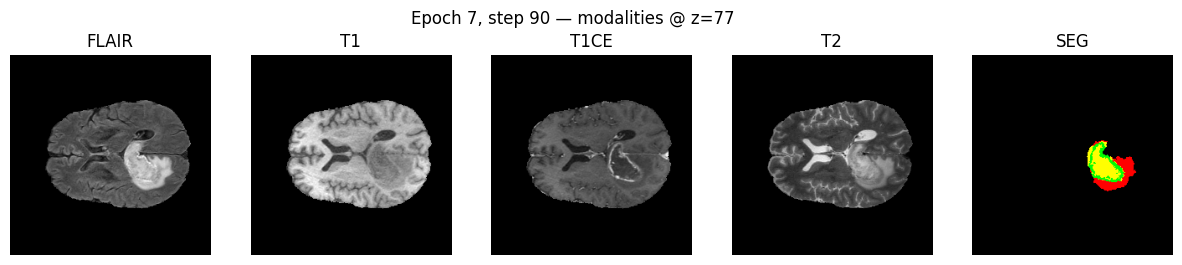

Epoch 7/30: 100%|██████████| 92/92 [04:04<00:00,  2.66s/it]


Epoch 07/30  avg loss = 0.27906


Epoch 8/30:  49%|████▉     | 45/92 [01:54<03:07,  4.00s/it]

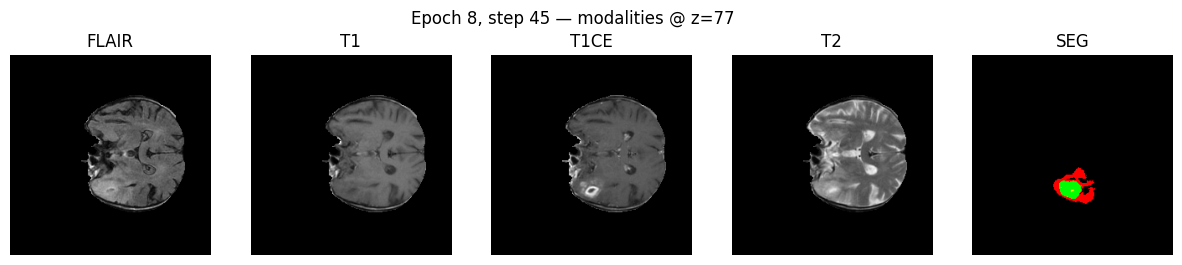

Epoch 8/30:  98%|█████████▊| 90/92 [04:13<00:06,  3.04s/it]

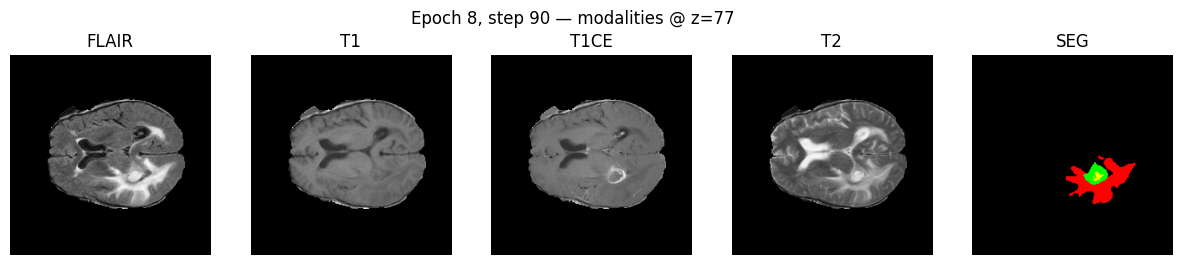

Epoch 8/30: 100%|██████████| 92/92 [04:22<00:00,  2.85s/it]


Epoch 08/30  avg loss = 0.26071


Epoch 9/30:  49%|████▉     | 45/92 [01:58<02:34,  3.28s/it]

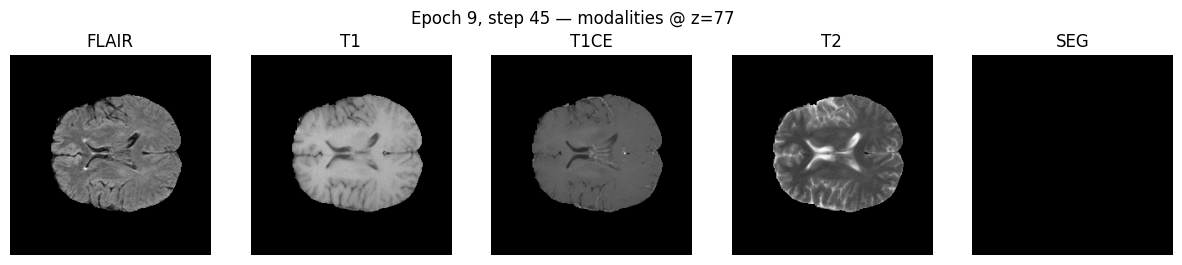

Epoch 9/30:  98%|█████████▊| 90/92 [04:18<00:06,  3.30s/it]

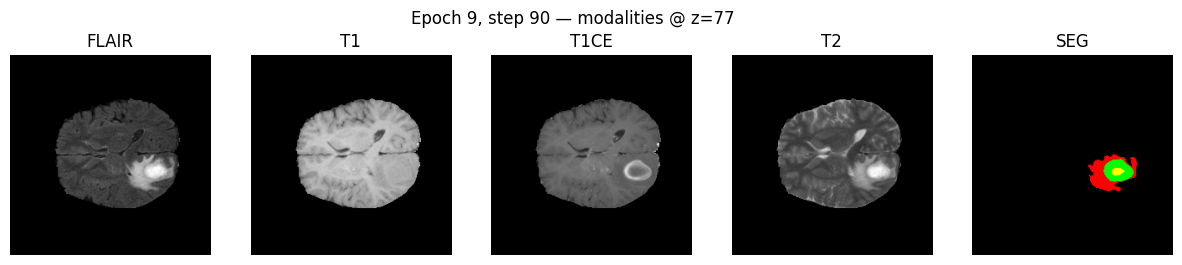

Epoch 9/30: 100%|██████████| 92/92 [04:22<00:00,  2.85s/it]


Epoch 09/30  avg loss = 0.27863


Epoch 10/30:  25%|██▌       | 23/92 [00:55<02:59,  2.60s/it]

In [ ]:
# NII save path
OUTPUT_ROOT = '/content/drive/MyDrive/brats_saved'
MODS = ['flair','t1','t1ce','t2','seg']
for m in MODS:
    os.makedirs(os.path.join(OUTPUT_ROOT, m), exist_ok=True)

# ----------------------------------------------------------------
# Colormap setup for segmentation labels
# ----------------------------------------------------------------
label_colors = {
    0: (0.0, 0.0, 0.0),   # background → black
    1: (1.0, 1.0, 0.0),   # label 1 → yellow
    2: (1.0, 0.0, 0.0),   # label 2 → red
    4: (0.0, 1.0, 0.0),   # label 4 → green
}
classes = sorted(label_colors.keys())
cmap   = colors.ListedColormap([label_colors[c] for c in classes])
bounds = [c - 0.5 for c in classes] + [classes[-1] + 0.5]
norm   = colors.BoundaryNorm(bounds, cmap.N)

# ----------------------------------------------------------------
# Training loop with colored seg panels
# ----------------------------------------------------------------
for epoch in range(1, EPOCHS + 1):
    total = tf.constant(0.0, tf.float32)
    steps = tf.constant(0, tf.int32)

    with tqdm(total=tf.data.experimental.cardinality(ds).numpy(),
              desc=f"Epoch {epoch}/{EPOCHS}") as pbar:
        for window_batch, path_batch in ds:
            loss = train_step(window_batch)
            total += loss
            steps += 1
            pbar.update(1)

            # every 45 steps, show & save modalities
            if tf.equal(steps % 45, 0):
                fpath    = path_batch[0].numpy().decode('utf-8')
                subj_dir = os.path.dirname(fpath)

                # load FLAIR to find central slice index
                flair = nib.load(fpath).get_fdata().astype(np.float32)
                iz    = flair.shape[2] // 2

                fig, axes = plt.subplots(1, len(MODS), figsize=(15, 3))
                for ax, m in zip(axes, MODS):
                    mod_fn   = os.path.basename(fpath).replace('flair', m)
                    mod_path = os.path.join(subj_dir, mod_fn)

                    # load raw data
                    vol = nib.load(mod_path).get_fdata()
                    sl  = vol[:, :, iz]

                    # save the full volume as .nii (normalized to [-1,1])
                    mn, mx  = sl.min(), sl.max()
                    norm_vol = (vol - mn) / (mx - mn) * 2 - 1
                    out_fn   = mod_fn.replace('.nii',
                                              f'_ep{epoch:02d}_st{steps.numpy():03d}.nii')
                    out_dir  = os.path.join(OUTPUT_ROOT, m)
                    out_path = os.path.join(out_dir, out_fn)
                    nib.save(
                        nib.Nifti1Image(norm_vol.astype(np.float32),
                                        affine=nib.load(mod_path).affine),
                        out_path
                    )

                    # plot
                    if m == 'seg':
                        # integer labels with discrete colormap
                        im = ax.imshow(sl.astype(int), cmap=cmap, norm=norm)
                    else:
                        # show other modalities in gray (normalized slice)
                        sl_norm = (sl - mn) / (mx - mn) * 2 - 1
                        ax.imshow(sl_norm, cmap='gray')

                    ax.set_title(m.upper())
                    ax.axis('off')

                plt.suptitle(f"Epoch {epoch}, step {steps.numpy()} — modalities @ z={iz}")
                plt.show()

    avg = total / tf.cast(steps, tf.float32)
    print(f"Epoch {epoch:02d}/{EPOCHS}  avg loss = {avg:.5f}")


# ----------------------------------------------------------------
# Pick one saved .nii and show its shape:
# ----------------------------------------------------------------
all_flair = glob.glob(os.path.join(OUTPUT_ROOT, 'flair', '*.nii'))
sample    = all_flair[0]
nii       = nib.load(sample)
print("Picked file:", sample)
print("Shape is:", nii.get_fdata().shape)

